# FM broadcast centre-frequency notebook

This notebook is standalone. It writes the stage modules into the current working directory, imports them, and runs an end-to-end synthetic WBFM integration test.

Run the cells from top to bottom.

In [1]:

import sys
import logging
import importlib
from pathlib import Path

# Ensure the current notebook directory is importable
cwd = str(Path.cwd().resolve())
if cwd not in sys.path:
    sys.path.insert(0, cwd)

# Early dependency check
missing = []
for pkg in ("numpy", "scipy"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    raise ImportError(
        f"Missing required package(s): {', '.join(missing)}. "
        f"Install them with: pip install {' '.join(missing)}"
    )

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s: %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

print("Environment ready.")
print("Working directory:", cwd)

Environment ready.
Working directory: /data/notebook_files


In [1]:
%%writefile stage1_acquisition.py
"""
Stage 1 - IQ acquisition from SigMF database (GitHub).
This replaces direct HackRF hardware capture for notebook workflows.
"""

from __future__ import annotations

import datetime
import logging
from dataclasses import dataclass, field
from typing import Optional

import diskcache as dc
import numpy as np
import requests

logger = logging.getLogger(__name__)

DB_BASE_URL = "https://raw.githubusercontent.com/dramirezbe/DataBase-IQ-FM-88MHz-108MHz/main/"
DB_TREE_URL = (
    "https://api.github.com/repos/dramirezbe/"
    "DataBase-IQ-FM-88MHz-108MHz/git/trees/main?recursive=1"
)

DEFAULT_CACHE_DIR = "dataset_cache"
DEFAULT_MEASURES = list(range(1, 31))


@dataclass
class IQParams:
    center_freq: int
    sample_rate: int
    lna: int
    vga: int
    amp_enabled: bool


@dataclass
class AcquisitionConfig:
    target_frequency_hz: int
    offset_frequency_hz: int
    sample_rate_hz: int
    num_samples: int
    if_gain_db: int
    baseband_gain_db: int
    amp_enable: bool
    record_number: int
    centre_frequency_hz: int = field(init=False)
    total_gain_db: int = field(init=False)

    @property
    def lna_gain_db(self) -> int:
        return self.if_gain_db

    @property
    def vga_gain_db(self) -> int:
        return self.baseband_gain_db

    def __post_init__(self) -> None:
        self.centre_frequency_hz = self.target_frequency_hz + self.offset_frequency_hz
        self.total_gain_db = self.if_gain_db + self.baseband_gain_db + (14 if self.amp_enable else 0)


@dataclass
class AcquisitionResult:
    samples: np.ndarray
    config: AcquisitionConfig
    timestamp_utc: str
    clipping_detected: bool = False


class SigMFRepo:
    def __init__(self, cache_dir: str = DEFAULT_CACHE_DIR):
        self.base_url = DB_BASE_URL
        self.cache = dc.Cache(cache_dir)
        self.tree = self._load_tree()

    def _load_tree(self) -> list[dict]:
        cache_key = "repo_tree"
        if cache_key in self.cache:
            return self.cache[cache_key]
        tree = requests.get(DB_TREE_URL, timeout=30).json().get("tree", [])
        self.cache[cache_key] = tree
        return tree

    def _find_pair(self, number: int) -> tuple[str, str]:
        prefix = f"{number:02d}"
        all_files = [item["path"] for item in self.tree if "path" in item]
        meta_matches = [
            p for p in all_files
            if p.startswith(prefix) and p.endswith(".sigmf-meta")
        ]
        if not meta_matches:
            raise FileNotFoundError(f"No SigMF metadata for measure {number} (prefix {prefix})")
        meta_file = meta_matches[0]
        data_file = meta_file.replace(".sigmf-meta", ".sigmf-data")
        return meta_file, data_file

    def get_measure(self, number: int) -> tuple[np.ndarray, IQParams]:
        meta_key = f"meta_{number:02d}"
        iq_key = f"iq_{number:02d}"

        if meta_key in self.cache and iq_key in self.cache:
            meta = self.cache[meta_key]
            raw_int = self.cache[iq_key]
        else:
            meta_file, data_file = self._find_pair(number)
            meta = requests.get(self.base_url + meta_file, timeout=30).json()
            raw_data = requests.get(self.base_url + data_file, timeout=60).content
            raw_int = np.frombuffer(raw_data, dtype=np.int8)
            self.cache[meta_key] = meta
            self.cache[iq_key] = raw_int

        params = IQParams(
            center_freq=int(meta["captures"][0]["core:frequency"]),
            sample_rate=int(meta["global"]["core:sample_rate"]),
            lna=int(meta["global"].get("hackrf:lna_gain_db", 0)),
            vga=int(meta["global"].get("hackrf:vga_gain_db", 0)),
            amp_enabled=bool(meta["global"].get("hackrf:amp_enabled", False)),
        )

        return raw_int, params


def make_config(
    target_hz: int,
    sample_rate_hz: int,
    if_gain_db: int,
    baseband_gain_db: int,
    amp_enable: bool,
    record_number: int,
    num_samples: int,
    offset_hz: Optional[int] = None,
) -> AcquisitionConfig:
    if offset_hz is None:
        offset_hz = sample_rate_hz // 4
    return AcquisitionConfig(
        target_frequency_hz=target_hz,
        offset_frequency_hz=offset_hz,
        sample_rate_hz=sample_rate_hz,
        num_samples=num_samples,
        if_gain_db=if_gain_db,
        baseband_gain_db=baseband_gain_db,
        amp_enable=amp_enable,
        record_number=record_number,
    )


def _to_complex_iq(raw_iq_int8: np.ndarray) -> np.ndarray:
    i_raw = raw_iq_int8[0::2].astype(np.float32)
    q_raw = raw_iq_int8[1::2].astype(np.float32)
    return ((i_raw + 1j * q_raw) * (1.0 / 128.0)).astype(np.complex64)


def run_stage1(
    target_frequency_hz: Optional[int] = None,
    sample_rate_hz: Optional[int] = None,
    if_gain_db: Optional[int] = None,
    baseband_gain_db: Optional[int] = None,
    amp_enable: Optional[bool] = None,
    device_index: int = 0,
    lna_gain_db: Optional[int] = None,
    vga_gain_db: Optional[int] = None,
    record_number: int = 1,
    num_samples: Optional[int] = None,
    cache_dir: str = DEFAULT_CACHE_DIR,
) -> AcquisitionResult:
    del device_index  # Kept for backward-compatible signature.

    repo = SigMFRepo(cache_dir=cache_dir)
    raw_int, params = repo.get_measure(record_number)

    if lna_gain_db is not None:
        if_gain_db = lna_gain_db
    if vga_gain_db is not None:
        baseband_gain_db = vga_gain_db

    target = int(params.center_freq if target_frequency_hz is None else target_frequency_hz)
    sr = int(params.sample_rate if sample_rate_hz is None else sample_rate_hz)
    ifg = int(params.lna if if_gain_db is None else if_gain_db)
    bbg = int(params.vga if baseband_gain_db is None else baseband_gain_db)
    amp = bool(params.amp_enabled if amp_enable is None else amp_enable)

    iq = _to_complex_iq(raw_int)
    if num_samples is None:
        num_samples = int(iq.size)
    iq = iq[:num_samples]

    cfg = make_config(
        target_hz=target,
        sample_rate_hz=sr,
        if_gain_db=ifg,
        baseband_gain_db=bbg,
        amp_enable=amp,
        record_number=record_number,
        num_samples=len(iq),
    )

    clipping = bool(np.any((raw_int == 127) | (raw_int == -128)))
    timestamp = datetime.datetime.now(datetime.timezone.utc).isoformat().replace("+00:00", "Z")

    logger.info(
        "Loaded IQ measure %02d from DB: n=%d, f0=%.3f MHz, fs=%.3f Msps",
        record_number,
        len(iq),
        cfg.target_frequency_hz / 1e6,
        cfg.sample_rate_hz / 1e6,
    )

    return AcquisitionResult(
        samples=iq,
        config=cfg,
        timestamp_utc=timestamp,
        clipping_detected=clipping,
    )


def load_iq_records(
    numbers: Optional[list[int]] = None,
    cache_dir: str = DEFAULT_CACHE_DIR,
    num_samples: Optional[int] = None,
) -> list[AcquisitionResult]:
    if numbers is None:
        numbers = DEFAULT_MEASURES
    records: list[AcquisitionResult] = []
    for n in numbers:
        records.append(run_stage1(record_number=int(n), cache_dir=cache_dir, num_samples=num_samples))
    return records

Writing stage1_acquisition.py


In [2]:
%%writefile stage2_preprocessing.py
"""
Stage 2 — Preprocessing
FM Broadcast Centre-Frequency Estimation Pipeline
"""

from __future__ import annotations

import datetime
import logging
import uuid

import numpy as np
from scipy.signal import windows as sig_windows

from dataclasses import dataclass
from typing import Optional

from stage1_acquisition import AcquisitionResult, AcquisitionConfig

logger = logging.getLogger(__name__)

DC_GUARD_BINS_DEFAULT:     int   = 5
DC_INTERP_CONTEXT_BINS:    int   = 4

IQ_MIRROR_REJECTION_FLOOR: float = -40.0
IQ_REF_TONE_OFFSET_HZ:     float = 1_000_000.0

NOISE_PERCENTILE_DEFAULT:  float = 10.0
NOISE_FRAME_COUNT_DEFAULT: int   = 16
FFT_SIZE_NOISE:            int   = 4096


@dataclass
class IQCalibration:
    amplitude_imbalance_factor: float = 1.0
    phase_error_rad:            float = 0.0
    calibration_timestamp_utc:  str   = "uncalibrated"
    calibration_state_id:       str   = "default"

    @property
    def amplitude_imbalance_db(self) -> float:
        return 20.0 * np.log10(max(self.amplitude_imbalance_factor, 1e-12))

    @property
    def phase_error_deg(self) -> float:
        return float(np.degrees(self.phase_error_rad))

    def build_correction_matrix(self) -> np.ndarray:
        phi = float(self.phase_error_rad)
        g   = float(max(self.amplitude_imbalance_factor, 1e-12))
        return np.array([
            [1.0,           0.0],
            [-np.sin(phi),  np.cos(phi) / g],
        ], dtype=np.float64)

    def to_dict(self) -> dict:
        return {
            "amplitude_imbalance_factor": self.amplitude_imbalance_factor,
            "phase_error_rad":            self.phase_error_rad,
            "calibration_timestamp_utc":  self.calibration_timestamp_utc,
            "calibration_state_id":       self.calibration_state_id,
        }

    @classmethod
    def from_dict(cls, d: dict) -> "IQCalibration":
        return cls(**d)


def estimate_iq_calibration(
    samples:            np.ndarray,
    sample_rate_hz:     int,
    ref_tone_offset_hz: float = IQ_REF_TONE_OFFSET_HZ,
    fft_size:           int   = 65536,
    window_type:        str   = "blackmanharris",
) -> IQCalibration:
    if fft_size <= 0:
        raise ValueError("fft_size must be positive")
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")
    if len(samples) == 0:
        raise ValueError("samples must be non-empty")

    n = min(len(samples), fft_size)
    if n < 16:
        raise ValueError("not enough samples for calibration estimation")

    window = sig_windows.get_window(window_type, n, fftbins=True)
    window = window / np.sqrt(np.mean(window ** 2))

    spectrum = np.fft.fftshift(np.fft.fft(samples[:n] * window, n=n))

    bin_spacing = sample_rate_hz / n
    ref_bin     = int(round( ref_tone_offset_hz / bin_spacing)) + n // 2
    mirror_bin  = int(round(-ref_tone_offset_hz / bin_spacing)) + n // 2

    if not (0 <= ref_bin < n and 0 <= mirror_bin < n):
        raise ValueError("ref_tone_offset_hz lies outside the FFT span")

    ref_val    = spectrum[ref_bin]
    mirror_val = spectrum[mirror_bin]

    g   = float(np.abs(ref_val) / max(np.abs(mirror_val), 1e-12))
    phi = float(np.angle(mirror_val) - np.angle(ref_val) + np.pi) / 2.0

    timestamp_utc = datetime.datetime.now(datetime.timezone.utc).isoformat().replace("+00:00", "Z")

    logger.info(
        "I/Q calibration estimated from reference tone: g=%.4f (%.2f dB)  φ=%.4f rad (%.2f°)",
        g, 20 * np.log10(max(g, 1e-12)), phi, np.degrees(phi),
    )

    return IQCalibration(
        amplitude_imbalance_factor = g,
        phase_error_rad            = phi,
        calibration_timestamp_utc  = timestamp_utc,
        calibration_state_id       = f"cal_{uuid.uuid4().hex[:12]}",
    )


@dataclass
class DCSpikeRemovalResult:
    samples_corrected:   np.ndarray
    dc_guard_band_hz:    float
    guard_bins_applied:  int
    peak_dc_power_db:    float


def remove_dc_spike(
    samples:         np.ndarray,
    sample_rate_hz:  int,
    fft_size:        int = FFT_SIZE_NOISE,
    guard_bins:      int = DC_GUARD_BINS_DEFAULT,
    context_bins:    int = DC_INTERP_CONTEXT_BINS,
) -> DCSpikeRemovalResult:
    if fft_size <= 0:
        raise ValueError("fft_size must be positive")
    if guard_bins < 0:
        raise ValueError("guard_bins must be non-negative")
    if context_bins < 1:
        raise ValueError("context_bins must be at least 1")
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")
    if len(samples) == 0:
        raise ValueError("samples must be non-empty")
    if 2 * (guard_bins + context_bins) + 1 >= fft_size:
        raise ValueError("guard/context region is too large for the chosen fft_size")

    logger.debug(
        "2a DC mitigation: guard_bins=±%d  context_bins=%d  fft_size=%d",
        guard_bins, context_bins, fft_size,
    )

    n_complete = len(samples) // fft_size
    corrected_blocks: list[np.ndarray] = []
    peak_dc_powers:   list[float]      = []

    dc_idx      = fft_size // 2
    lo_guard    = max(dc_idx - guard_bins, 0)
    hi_guard    = min(dc_idx + guard_bins, fft_size - 1)
    lo_ctx_s    = max(lo_guard - context_bins, 0)
    hi_ctx_e    = min(hi_guard + 1 + context_bins, fft_size)

    lo_ctx_bins = np.arange(lo_ctx_s,     lo_guard)
    hi_ctx_bins = np.arange(hi_guard + 1, hi_ctx_e)
    ctx_bins    = np.concatenate([lo_ctx_bins, hi_ctx_bins])
    fill_bins   = np.arange(lo_guard, hi_guard + 1)

    if ctx_bins.size < 2:
        raise ValueError("insufficient interpolation context around the DC guard region")

    for i in range(n_complete):
        block    = samples[i * fft_size : (i + 1) * fft_size].copy()
        spectrum = np.fft.fftshift(np.fft.fft(block))

        peak_dc_powers.append(
            float(10.0 * np.log10(max(np.abs(spectrum[dc_idx]) ** 2, 1e-30)))
        )

        ctx_vals     = spectrum[ctx_bins]
        amp_interp   = np.interp(fill_bins, ctx_bins, np.abs(ctx_vals))
        phase_interp = np.interp(fill_bins, ctx_bins, np.unwrap(np.angle(ctx_vals)))
        spectrum[fill_bins] = amp_interp * np.exp(1j * phase_interp)

        corrected_blocks.append(
            np.fft.ifft(np.fft.ifftshift(spectrum)).astype(np.complex64)
        )

    remainder = samples[n_complete * fft_size :]
    if len(remainder):
        corrected_blocks.append(remainder.astype(np.complex64, copy=False))

    corrected = np.concatenate(corrected_blocks) if corrected_blocks else samples.astype(np.complex64, copy=False)
    peak_dc_power_db = float(np.mean(peak_dc_powers)) if peak_dc_powers else float("nan")
    guard_band_hz = (2 * guard_bins + 1) * sample_rate_hz / fft_size

    logger.debug(
        "DC mitigation complete: guard_band=%.1f kHz  mean_DC_bin_power=%.1f dB(rel)",
        guard_band_hz / 1e3, peak_dc_power_db,
    )

    return DCSpikeRemovalResult(
        samples_corrected  = corrected,
        dc_guard_band_hz   = guard_band_hz,
        guard_bins_applied = guard_bins,
        peak_dc_power_db   = peak_dc_power_db,
    )


@dataclass
class IQCorrectionResult:
    samples_corrected:      np.ndarray
    amplitude_imbalance_db: float
    phase_imbalance_deg:    float
    mirror_power_before_db: float
    mirror_power_after_db:  float
    mirror_suppression_db:  float
    iq_residual_flag:       bool
    diagnostic_tone_used:   bool


def correct_iq_imbalance(
    samples:              np.ndarray,
    calibration:          IQCalibration,
    sample_rate_hz:       int,
    fft_size:             int              = FFT_SIZE_NOISE,
    eval_tone_offset_hz:  Optional[float]  = None,
) -> IQCorrectionResult:
    if fft_size <= 0:
        raise ValueError("fft_size must be positive")
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")
    if len(samples) == 0:
        raise ValueError("samples must be non-empty")

    logger.debug(
        "2b I/Q correction: g=%.4f (%.2f dB)  φ=%.4f rad (%.2f°)",
        calibration.amplitude_imbalance_factor,
        calibration.amplitude_imbalance_db,
        calibration.phase_error_rad,
        calibration.phase_error_deg,
    )

    C = calibration.build_correction_matrix()

    iq_matrix = np.vstack([
        samples.real.astype(np.float64),
        samples.imag.astype(np.float64),
    ])
    iq_corrected = C @ iq_matrix
    corrected    = (iq_corrected[0] + 1j * iq_corrected[1]).astype(np.complex64)

    diagnostic_tone_used = eval_tone_offset_hz is not None

    if not diagnostic_tone_used:
        logger.debug("No diagnostic tone specified for I/Q evaluation; mirror metrics set to NaN.")
        return IQCorrectionResult(
            samples_corrected      = corrected,
            amplitude_imbalance_db = calibration.amplitude_imbalance_db,
            phase_imbalance_deg    = calibration.phase_error_deg,
            mirror_power_before_db = float("nan"),
            mirror_power_after_db  = float("nan"),
            mirror_suppression_db  = float("nan"),
            iq_residual_flag       = False,
            diagnostic_tone_used   = False,
        )

    n = min(len(samples), fft_size)
    bin_spacing = sample_rate_hz / n
    mirror_bin  = int(round(-eval_tone_offset_hz / bin_spacing)) + n // 2
    ref_bin     = int(round( eval_tone_offset_hz / bin_spacing)) + n // 2

    if not (0 <= ref_bin < n and 0 <= mirror_bin < n):
        raise ValueError("eval_tone_offset_hz lies outside the FFT span for the chosen fft_size")

    def _mirror_power(s: np.ndarray) -> tuple[float, float]:
        spec     = np.fft.fftshift(np.fft.fft(s[:n], n=n))
        ref_p    = float(np.abs(spec[ref_bin]) ** 2)
        mirror_p = float(np.abs(spec[mirror_bin]) ** 2)
        return (
            10.0 * np.log10(max(ref_p, 1e-30)),
            10.0 * np.log10(max(mirror_p, 1e-30)),
        )

    ref_before, mirror_before = _mirror_power(samples)
    ref_after,  mirror_after  = _mirror_power(corrected)

    mirror_before_dbc = mirror_before - ref_before
    mirror_after_dbc  = mirror_after  - ref_after
    suppression_db    = mirror_before_dbc - mirror_after_dbc

    iq_residual_flag = bool(mirror_after_dbc > IQ_MIRROR_REJECTION_FLOOR)

    if iq_residual_flag:
        logger.warning(
            "IQ residual remains high: mirror %.1f dBc > %.1f dBc threshold.",
            mirror_after_dbc, IQ_MIRROR_REJECTION_FLOOR,
        )
    else:
        logger.debug(
            "Diagnostic tone mirror: before=%.1f dBc  after=%.1f dBc  suppression=%.1f dB",
            mirror_before_dbc, mirror_after_dbc, suppression_db,
        )

    return IQCorrectionResult(
        samples_corrected      = corrected,
        amplitude_imbalance_db = calibration.amplitude_imbalance_db,
        phase_imbalance_deg    = calibration.phase_error_deg,
        mirror_power_before_db = mirror_before_dbc,
        mirror_power_after_db  = mirror_after_dbc,
        mirror_suppression_db  = suppression_db,
        iq_residual_flag       = iq_residual_flag,
        diagnostic_tone_used   = True,
    )


@dataclass
class NoiseFloorResult:
    noise_floor_db:      np.ndarray
    noise_floor_mean_db: float
    percentile_used:     float
    frames_used:         int
    fft_size:            int
    freq_axis_hz:        np.ndarray


def estimate_noise_floor(
    samples:              np.ndarray,
    sample_rate_hz:       int,
    centre_frequency_hz:  int,
    fft_size:             int   = FFT_SIZE_NOISE,
    percentile:           float = NOISE_PERCENTILE_DEFAULT,
    n_frames:             int   = NOISE_FRAME_COUNT_DEFAULT,
    window_type:          str   = "blackmanharris",
) -> NoiseFloorResult:
    if fft_size <= 0:
        raise ValueError("fft_size must be positive")
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")
    if not (0.0 <= percentile <= 100.0):
        raise ValueError("percentile must lie in [0, 100]")
    if n_frames <= 0:
        raise ValueError("n_frames must be positive")
    if len(samples) < fft_size:
        raise ValueError(
            "not enough samples for one noise-estimation frame; increase capture length or reduce fft_size"
        )

    logger.debug(
        "2c Noise-floor estimation: fft_size=%d  percentile=%.1f%%  K=%d",
        fft_size, percentile, n_frames,
    )

    window  = sig_windows.get_window(window_type, fft_size, fftbins=True)
    window /= np.sqrt(np.mean(window ** 2))

    available = len(samples) // fft_size
    k_actual  = min(n_frames, available)
    if k_actual < n_frames:
        logger.warning(
            "Only %d frames available (requested %d); reduce fft_size or increase num_samples.",
            k_actual, n_frames,
        )

    frames     = samples[: k_actual * fft_size].reshape(k_actual, fft_size)
    psd_frames = np.empty((k_actual, fft_size), dtype=np.float64)

    for m, frame in enumerate(frames):
        spectrum      = np.fft.fftshift(np.fft.fft(frame * window))
        psd_frames[m] = np.abs(spectrum) ** 2

    noise_linear = np.percentile(psd_frames, percentile, axis=0)
    noise_db     = 10.0 * np.log10(np.maximum(noise_linear, 1e-30))

    freq_axis = (
        np.fft.fftshift(np.fft.fftfreq(fft_size, d=1.0 / sample_rate_hz))
        + centre_frequency_hz
    )

    noise_mean_db = float(np.mean(noise_db))

    logger.debug(
        "Noise baseline: mean=%.1f dB  min=%.1f dB  max=%.1f dB  using %d/%d frames",
        noise_mean_db,
        float(np.min(noise_db)),
        float(np.max(noise_db)),
        k_actual,
        n_frames,
    )

    return NoiseFloorResult(
        noise_floor_db      = noise_db,
        noise_floor_mean_db = noise_mean_db,
        percentile_used     = percentile,
        frames_used         = k_actual,
        fft_size            = fft_size,
        freq_axis_hz        = freq_axis,
    )


@dataclass
class PreprocessingResult:
    samples:            np.ndarray
    dc_result:          DCSpikeRemovalResult
    iq_result:          IQCorrectionResult
    noise_result:       NoiseFloorResult
    acquisition_config: AcquisitionConfig
    timestamp_utc:      str

    @property
    def dc_guard_band_hz(self) -> float:
        return self.dc_result.dc_guard_band_hz

    @property
    def noise_floor_db(self) -> np.ndarray:
        return self.noise_result.noise_floor_db

    @property
    def noise_floor_mean_db(self) -> float:
        return self.noise_result.noise_floor_mean_db

    @property
    def iq_residual_flag(self) -> bool:
        return self.iq_result.iq_residual_flag


def run_stage2(
    acq_result:          AcquisitionResult,
    calibration:         Optional[IQCalibration] = None,
    fft_size:            int = FFT_SIZE_NOISE,
    guard_bins:          int = DC_GUARD_BINS_DEFAULT,
    noise_percentile:    float = NOISE_PERCENTILE_DEFAULT,
    noise_frames:        int = NOISE_FRAME_COUNT_DEFAULT,
    eval_tone_offset_hz: Optional[float] = None,
) -> PreprocessingResult:
    samples = acq_result.samples
    cfg     = acq_result.config

    if calibration is None:
        logger.warning("No IQCalibration provided; using identity calibration (g=1, φ=0).")
        calibration = IQCalibration()

    dc_result = remove_dc_spike(
        samples         = samples,
        sample_rate_hz  = cfg.sample_rate_hz,
        fft_size        = fft_size,
        guard_bins      = guard_bins,
    )

    iq_result = correct_iq_imbalance(
        samples             = dc_result.samples_corrected,
        calibration         = calibration,
        sample_rate_hz      = cfg.sample_rate_hz,
        fft_size            = fft_size,
        eval_tone_offset_hz = eval_tone_offset_hz,
    )

    noise_result = estimate_noise_floor(
        samples              = iq_result.samples_corrected,
        sample_rate_hz       = cfg.sample_rate_hz,
        centre_frequency_hz  = cfg.centre_frequency_hz,
        fft_size             = fft_size,
        percentile           = noise_percentile,
        n_frames             = noise_frames,
    )

    result = PreprocessingResult(
        samples            = iq_result.samples_corrected,
        dc_result          = dc_result,
        iq_result          = iq_result,
        noise_result       = noise_result,
        acquisition_config = cfg,
        timestamp_utc      = acq_result.timestamp_utc,
    )

    if result.iq_result.diagnostic_tone_used:
        logger.info(
            "Stage 2 complete: DC guard=%.1f kHz  IQ mirror=%.1f dBc→%.1f dBc (Δ%.1f dB)  "
            "Noise baseline mean=%.1f dB  IQ_RESIDUAL=%s",
            result.dc_guard_band_hz / 1e3,
            result.iq_result.mirror_power_before_db,
            result.iq_result.mirror_power_after_db,
            result.iq_result.mirror_suppression_db,
            result.noise_floor_mean_db,
            result.iq_residual_flag,
        )
    else:
        logger.info(
            "Stage 2 complete: DC guard=%.1f kHz  IQ correction applied (no diagnostic tone)  "
            "Noise baseline mean=%.1f dB",
            result.dc_guard_band_hz / 1e3,
            result.noise_floor_mean_db,
        )

    return result

Writing stage2_preprocessing.py


In [3]:
%%writefile stage3_spectral_estimation.py
"""
Stage 3 — Spectral Estimation
FM Broadcast Centre-Frequency Estimation Pipeline
"""

from __future__ import annotations

import logging
import time

import numpy as np
from scipy.signal import windows as sig_windows

from dataclasses import dataclass
from typing import Optional

from stage1_acquisition import AcquisitionConfig
from stage2_preprocessing import PreprocessingResult, NoiseFloorResult

logger = logging.getLogger(__name__)

FFT_SIZE_DEFAULT:         int = 8192
FFT_SIZE_HIGH_RES:        int = 65536
AVERAGING_FRAMES_MIN:     int = 4
AVERAGING_FRAMES_DEFAULT: int = 16

WINDOW_DEFAULT: str = "blackmanharris"
WINDOW_ALTERNATIVES: dict[str, float] = {
    "blackmanharris": -92.0,
    "flattop":        -93.6,
    "hann":           -31.5,
    "hamming":        -43.0,
    "boxcar":         -13.3,
}

ADC_FULL_SCALE_DBM: float = -10.0
FREQ_AXIS_CORRECTION_FLOOR_HZ: float = 1.0


@dataclass
class GainCalibration:
    receiver_gain_db: float
    cable_loss_db: float = 0.0
    antenna_gain_dbi: float = 0.0
    frequency_response_correction_db: Optional[np.ndarray] = None
    calibration_state_id: str = "default"
    apply_antenna_gain_correction: bool = False

    @property
    def scalar_correction_db(self) -> float:
        antenna_term = -self.antenna_gain_dbi if self.apply_antenna_gain_correction else 0.0
        return ADC_FULL_SCALE_DBM - self.receiver_gain_db + self.cable_loss_db + antenna_term

    @classmethod
    def from_acquisition_config(
        cls,
        cfg: AcquisitionConfig,
        cable_loss_db: float = 0.0,
        antenna_gain_dbi: float = 0.0,
        apply_antenna_gain_correction: bool = False,
    ) -> "GainCalibration":
        return cls(
            receiver_gain_db              = cfg.total_gain_db,
            cable_loss_db                 = cable_loss_db,
            antenna_gain_dbi              = antenna_gain_dbi,
            calibration_state_id          = f"from_acq_{cfg.total_gain_db}dB",
            apply_antenna_gain_correction = apply_antenna_gain_correction,
        )


@dataclass
class WindowSpec:
    name:                 str
    fft_size:             int
    coefficients:         np.ndarray
    window_power_sum:     float
    power_norm_factor:    float
    amplitude_correction: float
    sidelobe_db:          float
    coherent_gain:        float
    enbw_bins:            float


def build_window(name: str, fft_size: int) -> WindowSpec:
    if name not in WINDOW_ALTERNATIVES and name not in ("bartlett", "nuttall", "parzen", "triang"):
        logger.warning("Window '%s' is not in the recommended set for FM monitoring.", name)

    w = sig_windows.get_window(name, fft_size, fftbins=True).astype(np.float64)

    window_power_sum = float(np.sum(w ** 2))
    power_norm_factor = 1.0 / max(window_power_sum, 1e-30)
    amp_corr = 1.0 / max(float(np.mean(np.abs(w))), 1e-30)
    coherent_gain = float(np.sum(w)) / fft_size
    sidelobe = WINDOW_ALTERNATIVES.get(name, float("nan"))
    enbw_bins = fft_size * window_power_sum / max(float(np.sum(w)) ** 2, 1e-30)

    logger.debug(
        "Window '%s' N=%d: power_norm=%.6e  amp_corr=%.4f  coherent_gain=%.4f  "
        "ENBW=%.3f bins  sidelobe=%.1f dB",
        name, fft_size, power_norm_factor, amp_corr, coherent_gain, enbw_bins, sidelobe,
    )

    return WindowSpec(
        name                 = name,
        fft_size             = fft_size,
        coefficients         = w,
        window_power_sum     = window_power_sum,
        power_norm_factor    = power_norm_factor,
        amplitude_correction = amp_corr,
        sidelobe_db          = sidelobe,
        coherent_gain        = coherent_gain,
        enbw_bins            = enbw_bins,
    )


@dataclass
class SpectralFrame:
    psd_db:         np.ndarray
    frame_index:    int
    peak_bin:       int
    peak_power_db:  float


@dataclass
class SpectralEstimationResult:
    psd_dbm_hz:         np.ndarray
    freq_axis_hz:       np.ndarray

    fft_size:           int
    averaging_frames:   int
    window_name:        str
    window_spec:        WindowSpec

    gain_calibration:   GainCalibration
    scalar_correction_db: float
    freq_response_applied: bool

    target_frequency_hz:    int
    centre_frequency_hz:    int
    offset_correction_hz:   int
    bin_spacing_hz:         float

    noise_floor_db:         np.ndarray
    noise_floor_calibrated: np.ndarray

    frames:                 list[SpectralFrame]

    sample_rate_hz:         int
    peak_psd_dbm_hz:        float
    peak_frequency_hz:      float
    dynamic_range_db:       float
    computation_time_s:     float

    @property
    def bin_containing(self):
        def _find(freq_hz: float) -> int:
            return int(np.argmin(np.abs(self.freq_axis_hz - freq_hz)))
        return _find

    @property
    def psd_at(self):
        def _get(freq_hz: float) -> float:
            return float(self.psd_dbm_hz[self.bin_containing(freq_hz)])
        return _get


def build_frequency_axis(
    fft_size:             int,
    sample_rate_hz:       int,
    centre_frequency_hz:  int,
    offset_correction_hz: int,
) -> tuple[np.ndarray, float]:
    if fft_size <= 0:
        raise ValueError("fft_size must be positive")
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")

    bin_spacing = sample_rate_hz / fft_size
    baseband = np.fft.fftshift(np.fft.fftfreq(fft_size, d=1.0 / sample_rate_hz))
    freq_axis = baseband + centre_frequency_hz - offset_correction_hz

    if abs(offset_correction_hz) < FREQ_AXIS_CORRECTION_FLOOR_HZ:
        logger.warning(
            "offset_correction_hz=%.1f Hz is negligible; verify whether Stage 1 offset tuning "
            "was intentionally disabled.",
            offset_correction_hz,
        )

    return freq_axis.astype(np.float64), float(bin_spacing)


def welch_average(
    samples:         np.ndarray,
    sample_rate_hz:  int,
    window:          WindowSpec,
    n_frames:        int,
    collect_frames:  bool = True,
) -> tuple[np.ndarray, list[SpectralFrame]]:
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")

    N = window.fft_size
    w = window.coefficients
    denom = float(sample_rate_hz) * max(window.window_power_sum, 1e-30)

    available = len(samples) // N
    m_actual = min(n_frames, available)

    if m_actual < n_frames:
        logger.warning("Welch: only %d complete frames available (requested %d).", m_actual, n_frames)
    if m_actual < AVERAGING_FRAMES_MIN:
        raise ValueError(
            f"Welch averaging requires at least {AVERAGING_FRAMES_MIN} complete frames; only {m_actual} available."
        )

    psd_accum = np.zeros(N, dtype=np.float64)
    frame_list: list[SpectralFrame] = []

    for m in range(m_actual):
        block = samples[m * N : (m + 1) * N]
        spectrum = np.fft.fftshift(np.fft.fft(block * w, n=N))
        psd_m = (np.abs(spectrum) ** 2) / denom

        psd_accum += psd_m

        if collect_frames:
            psd_m_db = 10.0 * np.log10(np.maximum(psd_m, 1e-30))
            peak_bin = int(np.argmax(psd_m_db))
            frame_list.append(
                SpectralFrame(
                    psd_db        = psd_m_db,
                    frame_index   = m,
                    peak_bin      = peak_bin,
                    peak_power_db = float(psd_m_db[peak_bin]),
                )
            )

    psd_avg = psd_accum / m_actual
    return psd_avg, frame_list


def apply_gain_calibration(
    psd_linear: np.ndarray,
    cal:        GainCalibration,
) -> tuple[np.ndarray, float, bool]:
    psd_dbfs_hz = 10.0 * np.log10(np.maximum(psd_linear, 1e-30))
    scalar_corr_db = cal.scalar_correction_db
    psd_dbm_hz = psd_dbfs_hz + scalar_corr_db

    freq_response_applied = False
    if cal.frequency_response_correction_db is not None:
        fr = cal.frequency_response_correction_db
        if len(fr) == len(psd_dbm_hz):
            psd_dbm_hz = psd_dbm_hz + fr
            freq_response_applied = True
            logger.debug("Per-bin frequency-response correction applied.")
        else:
            logger.warning(
                "frequency_response_correction_db length %d != FFT size %d; skipping per-bin correction.",
                len(fr), len(psd_dbm_hz),
            )

    logger.debug(
        "Gain calibration: scalar_corr=%.2f dB  (ADC_FS=%.1f  Grx=%.1f  Lcable=%.1f  antenna_term=%s)",
        scalar_corr_db,
        ADC_FULL_SCALE_DBM,
        cal.receiver_gain_db,
        cal.cable_loss_db,
        "on" if cal.apply_antenna_gain_correction else "off",
    )

    return psd_dbm_hz.astype(np.float64), float(scalar_corr_db), freq_response_applied


def resample_noise_floor_relative(
    noise_result:         NoiseFloorResult,
    target_fft_size:      int,
    sample_rate_hz:       int,
    centre_frequency_hz:  int,
    offset_correction_hz: int,
) -> np.ndarray:
    src_size = noise_result.fft_size
    noise_db = noise_result.noise_floor_db

    if src_size <= 0:
        raise ValueError("noise_result.fft_size must be positive")
    if sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive")

    if src_size == target_fft_size:
        return noise_db.copy().astype(np.float64)

    src_freq = noise_result.freq_axis_hz - offset_correction_hz
    tgt_freq, _ = build_frequency_axis(
        target_fft_size,
        sample_rate_hz,
        centre_frequency_hz,
        offset_correction_hz,
    )

    resampled_db = np.interp(
        tgt_freq,
        src_freq,
        noise_db,
        left=noise_db[0],
        right=noise_db[-1],
    )
    return resampled_db.astype(np.float64)


def calibrate_relative_noise_floor(
    noise_floor_relative_db: np.ndarray,
    sample_rate_hz:          int,
    stage2_fft_size:         int,
    scalar_correction_db:    float,
) -> np.ndarray:
    stage2_density_offset_db = -10.0 * np.log10(float(sample_rate_hz) * float(stage2_fft_size))
    calibrated = noise_floor_relative_db + stage2_density_offset_db + scalar_correction_db
    return calibrated.astype(np.float64)


def validate_spectral_consistency(
    frames:      list[SpectralFrame],
    target_bin:  int,
    bin_window:  int = 20,
) -> tuple[float, float]:
    if not frames:
        raise ValueError("frames must be non-empty")

    lo = max(target_bin - bin_window, 0)
    hi = min(target_bin + bin_window + 1, len(frames[0].psd_db))

    per_frame_peaks = np.array([float(np.max(f.psd_db[lo:hi])) for f in frames], dtype=np.float64)
    return float(np.std(per_frame_peaks)), float(np.mean(per_frame_peaks))


def run_stage3(
    pre_result:        PreprocessingResult,
    gain_calibration:  Optional[GainCalibration] = None,
    fft_size:          int = FFT_SIZE_DEFAULT,
    n_frames:          int = AVERAGING_FRAMES_DEFAULT,
    window_name:       str = WINDOW_DEFAULT,
    collect_frames:    bool = True,
) -> SpectralEstimationResult:
    t0 = time.perf_counter()
    cfg = pre_result.acquisition_config

    if fft_size < FFT_SIZE_DEFAULT:
        raise ValueError(f"fft_size={fft_size} is below the specification minimum of {FFT_SIZE_DEFAULT}.")
    if fft_size & (fft_size - 1):
        raise ValueError(f"fft_size={fft_size} is not a power of two.")
    if n_frames < AVERAGING_FRAMES_MIN:
        raise ValueError(f"n_frames={n_frames} < minimum {AVERAGING_FRAMES_MIN}.")
    if window_name == "boxcar":
        raise ValueError("Boxcar window rejected: sidelobe suppression is inadequate for FM monitoring.")

    samples_needed = fft_size * n_frames
    if len(pre_result.samples) < samples_needed:
        raise ValueError(f"Insufficient samples: need {samples_needed:,}, have {len(pre_result.samples):,}.")

    if gain_calibration is None:
        logger.warning(
            "No GainCalibration provided; deriving an approximate calibration from Stage 1 gains. "
            "Absolute dBm/Hz accuracy should be treated as approximate."
        )
        gain_calibration = GainCalibration.from_acquisition_config(cfg)

    window = build_window(window_name, fft_size)

    logger.info(
        "Stage 3: FFT N=%d  M=%d  window='%s'  sidelobe=%.1f dB  ENBW=%.3f bins  bin_spacing=%.2f Hz",
        fft_size, n_frames, window_name, window.sidelobe_db, window.enbw_bins, cfg.sample_rate_hz / fft_size,
    )

    psd_linear, frame_records = welch_average(
        samples        = pre_result.samples,
        sample_rate_hz = cfg.sample_rate_hz,
        window         = window,
        n_frames       = n_frames,
        collect_frames = collect_frames,
    )

    freq_axis, bin_spacing = build_frequency_axis(
        fft_size             = fft_size,
        sample_rate_hz       = cfg.sample_rate_hz,
        centre_frequency_hz  = cfg.centre_frequency_hz,
        offset_correction_hz = cfg.offset_frequency_hz,
    )

    psd_dbm_hz, scalar_corr_db, fr_applied = apply_gain_calibration(
        psd_linear = psd_linear,
        cal        = gain_calibration,
    )

    noise_floor_rel = resample_noise_floor_relative(
        noise_result         = pre_result.noise_result,
        target_fft_size      = fft_size,
        sample_rate_hz       = cfg.sample_rate_hz,
        centre_frequency_hz  = cfg.centre_frequency_hz,
        offset_correction_hz = cfg.offset_frequency_hz,
    )

    noise_floor_cal = calibrate_relative_noise_floor(
        noise_floor_relative_db = noise_floor_rel,
        sample_rate_hz          = cfg.sample_rate_hz,
        stage2_fft_size         = pre_result.noise_result.fft_size,
        scalar_correction_db    = scalar_corr_db,
    )

    peak_bin = int(np.argmax(psd_dbm_hz))
    peak_psd = float(psd_dbm_hz[peak_bin])
    peak_freq = float(freq_axis[peak_bin])
    noise_mean = float(np.mean(noise_floor_cal))
    dynamic_range = peak_psd - noise_mean
    elapsed = time.perf_counter() - t0

    if frame_records:
        target_bin = int(np.argmin(np.abs(freq_axis - cfg.target_frequency_hz)))
        frame_peak_std_db, frame_peak_mean_db = validate_spectral_consistency(
            frame_records,
            target_bin=target_bin,
            bin_window=20,
        )
        logger.debug(
            "Frame consistency near target: mean=%.2f dBFS/Hz  std=%.2f dB",
            frame_peak_mean_db,
            frame_peak_std_db,
        )

    logger.info(
        "Stage 3 complete: dominant bin=%.1f dBm/Hz @ %.4f MHz  noise baseline=%.1f dBm/Hz  "
        "DR=%.1f dB  elapsed=%.0f ms",
        peak_psd, peak_freq / 1e6, noise_mean, dynamic_range, elapsed * 1e3,
    )

    return SpectralEstimationResult(
        psd_dbm_hz             = psd_dbm_hz,
        freq_axis_hz           = freq_axis,
        fft_size               = fft_size,
        averaging_frames       = len(frame_records) if collect_frames else n_frames,
        window_name            = window_name,
        window_spec            = window,
        gain_calibration       = gain_calibration,
        scalar_correction_db   = scalar_corr_db,
        freq_response_applied  = fr_applied,
        target_frequency_hz    = cfg.target_frequency_hz,
        centre_frequency_hz    = cfg.centre_frequency_hz,
        offset_correction_hz   = cfg.offset_frequency_hz,
        bin_spacing_hz         = bin_spacing,
        noise_floor_db         = noise_floor_rel,
        noise_floor_calibrated = noise_floor_cal,
        frames                 = frame_records,
        sample_rate_hz         = cfg.sample_rate_hz,
        peak_psd_dbm_hz        = peak_psd,
        peak_frequency_hz      = peak_freq,
        dynamic_range_db       = dynamic_range,
        computation_time_s     = elapsed,
    )

Writing stage3_spectral_estimation.py


In [4]:
%%writefile stage4_peak_detection.py
"""
Stage 4 — Channel Candidate Detection
FM Broadcast Centre-Frequency Estimation Pipeline

Occupied-region detection replaces local-max peak detection so the stage
tracks FM channel occupancy rather than a single spectral spike.
"""

from __future__ import annotations

import logging
import time

import numpy as np

from dataclasses import dataclass
from typing import Optional

from stage3_spectral_estimation import SpectralEstimationResult

logger = logging.getLogger(__name__)

# 4a — threshold
DETECTION_MARGIN_DB_DEFAULT:   float = 8.0
DETECTION_MARGIN_DB_MIN:       float = 6.0
DETECTION_MARGIN_DB_MAX:       float = 20.0

# 4b/4c — occupied-region modelling
PROMINENCE_MIN_DB:             float = 10.0
PROMINENCE_FLAG_DB:            float = 20.0
SADDLE_SEARCH_HALF_WIDTH_HZ:   float = 400_000.0
REGION_GAP_MAX_HZ:             float = 15_000.0

# 4d — occupied bandwidth plausibility
WIDTH_MIN_HZ:                  float = 40_000.0
WIDTH_MAX_HZ:                  float = 400_000.0
IDEAL_WIDTH_MIN_HZ:            float = 100_000.0
IDEAL_WIDTH_MAX_HZ:            float = 250_000.0

# 4e — artefact rejection
DC_PROXIMITY_GUARD_FACTOR:     float = 2.0
MIRROR_FREQ_TOLERANCE_HZ:      float = 5_000.0
MIRROR_POWER_MARGIN_DB:        float = 6.0
MIRROR_WIDTH_RATIO_MIN:        float = 0.5

MAX_HARMONIC_ORDER:            int   = 5
MAX_CANDIDATES_RETURNED:       int   = 8


@dataclass
class PeakCandidate:
    """
    One occupied-channel candidate.

    This object is region-centric:
      - centre_frequency_hz is the coarse channel-centre estimate
      - region_prominence_db measures the region peak above the outer shoulders
      - occupied_bandwidth_hz is the raw above-threshold span of the region
    """
    bin_index:                int
    centre_frequency_hz:      float
    deviation_from_target_hz: float

    peak_power_dbm_hz:        float
    noise_floor_at_peak_dbm_hz: float
    snr_db:                   float

    region_prominence_db:     float
    shoulder_power_dbm_hz:    float
    occupied_bandwidth_hz:    float

    region_start_bin:         int = 0
    region_end_bin:           int = 0
    edge_midpoint_hz:         float = 0.0
    power_centroid_hz:        float = 0.0
    ranking_score:            float = 0.0

    dc_proximity_flag:        bool = False
    mirror_flag:              bool = False
    harmonic_flag:            bool = False
    width_out_of_range_flag:  bool = False

    mirror_of_bin:            Optional[int] = None
    harmonic_order:           Optional[int] = None

    @property
    def is_artefact(self) -> bool:
        return self.mirror_flag or self.harmonic_flag

    @property
    def is_valid_carrier(self) -> bool:
        return (
            not self.is_artefact
            and not self.dc_proximity_flag
            and not self.width_out_of_range_flag
            and self.region_prominence_db >= PROMINENCE_MIN_DB
        )

    def summary(self) -> str:
        flags = []
        if self.dc_proximity_flag:
            flags.append("DC_PROXIMITY")
        if self.mirror_flag:
            flags.append(f"MIRROR(bin={self.mirror_of_bin})")
        if self.harmonic_flag:
            flags.append(f"HARMONIC(n={self.harmonic_order})")
        if self.width_out_of_range_flag:
            flags.append("WIDTH_OOR")
        flag_str = " ".join(flags) if flags else "—"
        return (
            f"{self.centre_frequency_hz/1e6:11.6f} MHz  "
            f"SNR {self.snr_db:5.1f} dB  "
            f"prom {self.region_prominence_db:5.1f} dB  "
            f"BW {self.occupied_bandwidth_hz/1e3:6.1f} kHz  "
            f"score {self.ranking_score:4.2f}  "
            f"flags [{flag_str}]  "
            f"valid={self.is_valid_carrier}"
        )


@dataclass
class PeakDetectionResult:
    candidates:           list[PeakCandidate]

    n_raw_regions:        int
    n_artefacts:          int
    n_dc_proximity:       int
    n_width_rejected:     int
    n_valid:              int

    threshold_dbm_hz:     np.ndarray
    detection_margin_db:  float

    target_frequency_hz:  int
    computation_time_s:   float

    @property
    def primary(self) -> Optional[PeakCandidate]:
        valid = [c for c in self.candidates if c.is_valid_carrier]
        return valid[0] if valid else None

    def report(self) -> str:
        lines = [
            f"Stage 4 — {len(self.candidates)} returned candidates "
            f"({self.n_valid} valid, {self.n_artefacts} artefacts, "
            f"{self.n_dc_proximity} DC-adj, {self.n_width_rejected} width-OOR)",
            f"  Detection margin : {self.detection_margin_db:.1f} dB",
            "  " + "─" * 78,
        ]
        for i, c in enumerate(self.candidates):
            tag = "►" if (c is self.primary) else " "
            lines.append(f"  {tag} [{i:02d}] {c.summary()}")
        return "\n".join(lines)


def build_threshold(
    noise_floor_calibrated: np.ndarray,
    detection_margin_db:    float = DETECTION_MARGIN_DB_DEFAULT,
) -> np.ndarray:
    if noise_floor_calibrated.ndim != 1:
        raise ValueError("noise_floor_calibrated must be a 1D array")

    if not (DETECTION_MARGIN_DB_MIN <= detection_margin_db <= DETECTION_MARGIN_DB_MAX):
        raise ValueError(
            f"detection_margin_db={detection_margin_db:.1f} outside "
            f"[{DETECTION_MARGIN_DB_MIN}, {DETECTION_MARGIN_DB_MAX}] dB."
        )

    threshold = noise_floor_calibrated + detection_margin_db
    logger.debug(
        "Threshold: margin=%.1f dB  mean=%.1f dBm/Hz  range=[%.1f, %.1f]",
        detection_margin_db,
        float(np.mean(threshold)),
        float(np.min(threshold)),
        float(np.max(threshold)),
    )
    return threshold.astype(np.float64)


def _close_small_gaps(mask: np.ndarray, max_gap_bins: int) -> np.ndarray:
    mask = mask.astype(bool).copy()
    if max_gap_bins <= 0:
        return mask

    n = len(mask)
    i = 0
    while i < n:
        if mask[i]:
            i += 1
            continue

        j = i
        while j < n and not mask[j]:
            j += 1

        gap_len = j - i
        left_true = (i > 0 and mask[i - 1])
        right_true = (j < n and mask[j])

        if left_true and right_true and gap_len <= max_gap_bins:
            mask[i:j] = True

        i = j

    return mask


def find_active_regions(
    psd_dbm_hz:      np.ndarray,
    threshold:       np.ndarray,
    *,
    max_gap_bins:    int,
    min_region_bins: int,
) -> list[tuple[int, int]]:
    if psd_dbm_hz.shape != threshold.shape:
        raise ValueError("psd_dbm_hz and threshold must have the same shape")

    mask = psd_dbm_hz > threshold
    mask = _close_small_gaps(mask, max_gap_bins=max_gap_bins)

    padded = np.r_[False, mask, False]
    starts = np.flatnonzero(~padded[:-1] & padded[1:])
    ends   = np.flatnonzero(padded[:-1] & ~padded[1:]) - 1

    regions: list[tuple[int, int]] = []
    for s, e in zip(starts, ends):
        if (e - s + 1) >= min_region_bins:
            regions.append((int(s), int(e)))

    logger.debug(
        "Occupied-region detection: %d regions above threshold "
        "(gap_close=%d bins, min_region=%d bins)",
        len(regions), max_gap_bins, min_region_bins,
    )
    return regions


def _db_to_power(x_db: np.ndarray) -> np.ndarray:
    return np.power(10.0, x_db / 10.0)


def assemble_channel_candidates(
    spec:                 SpectralEstimationResult,
    regions:              list[tuple[int, int]],
    shoulder_search_bins: int,
) -> list[PeakCandidate]:
    psd   = spec.psd_dbm_hz
    freq  = spec.freq_axis_hz
    noise = spec.noise_floor_calibrated

    candidates: list[PeakCandidate] = []

    for start_bin, end_bin in regions:
        sl = slice(start_bin, end_bin + 1)

        peak_bin = start_bin + int(np.argmax(psd[sl]))
        peak_power_dbm_hz = float(psd[peak_bin])

        noise_floor_at_peak_dbm_hz = float(np.median(noise[sl]))
        snr_db = peak_power_dbm_hz - noise_floor_at_peak_dbm_hz

        left_edge_hz  = float(freq[start_bin])
        right_edge_hz = float(freq[end_bin])
        occupied_bw_hz = right_edge_hz - left_edge_hz
        edge_midpoint_hz = 0.5 * (left_edge_hz + right_edge_hz)

        p_sig = np.maximum(_db_to_power(psd[sl]) - _db_to_power(noise[sl]), 0.0)
        if float(np.sum(p_sig)) > 0.0:
            power_centroid_hz = float(np.sum(freq[sl] * p_sig) / np.sum(p_sig))
        else:
            power_centroid_hz = edge_midpoint_hz

        left_ref_start = max(0, start_bin - shoulder_search_bins)
        left_ref_end   = start_bin
        right_ref_start = end_bin + 1
        right_ref_end   = min(len(psd), end_bin + 1 + shoulder_search_bins)

        left_ref  = float(np.max(psd[left_ref_start:left_ref_end])) if left_ref_end > left_ref_start else float(psd[start_bin])
        right_ref = float(np.max(psd[right_ref_start:right_ref_end])) if right_ref_end > right_ref_start else float(psd[end_bin])

        shoulder_power_dbm_hz = max(left_ref, right_ref)
        region_prominence_db = peak_power_dbm_hz - shoulder_power_dbm_hz

        width_out_of_range = not (WIDTH_MIN_HZ <= occupied_bw_hz <= WIDTH_MAX_HZ)

        candidate = PeakCandidate(
            bin_index                  = peak_bin,
            centre_frequency_hz        = edge_midpoint_hz,
            deviation_from_target_hz   = edge_midpoint_hz - spec.target_frequency_hz,
            peak_power_dbm_hz          = peak_power_dbm_hz,
            noise_floor_at_peak_dbm_hz = noise_floor_at_peak_dbm_hz,
            snr_db                     = snr_db,
            region_prominence_db       = region_prominence_db,
            shoulder_power_dbm_hz      = shoulder_power_dbm_hz,
            occupied_bandwidth_hz      = occupied_bw_hz,
            region_start_bin           = start_bin,
            region_end_bin             = end_bin,
            edge_midpoint_hz           = edge_midpoint_hz,
            power_centroid_hz          = power_centroid_hz,
            width_out_of_range_flag    = width_out_of_range,
        )

        candidates.append(candidate)

    return candidates


def flag_dc_proximity(
    freq_hz:          float,
    dc_frequency_hz:  float,
    dc_guard_band_hz: float,
    guard_factor:     float = DC_PROXIMITY_GUARD_FACTOR,
) -> bool:
    distance = abs(freq_hz - dc_frequency_hz)
    return distance < guard_factor * dc_guard_band_hz


def flag_mirror_images(
    candidates:      list[PeakCandidate],
    reflect_axis_hz: float,
    tolerance_hz:    float = MIRROR_FREQ_TOLERANCE_HZ,
    min_power_margin_db: float = MIRROR_POWER_MARGIN_DB,
) -> None:
    for i, a in enumerate(candidates):
        if a.mirror_flag:
            continue

        f_mirror = 2.0 * reflect_axis_hz - a.centre_frequency_hz

        for j, b in enumerate(candidates):
            if i == j or b.mirror_flag:
                continue

            if abs(b.centre_frequency_hz - f_mirror) > tolerance_hz:
                continue

            power_diff = a.peak_power_dbm_hz - b.peak_power_dbm_hz
            if abs(power_diff) < min_power_margin_db:
                continue

            bw_small = min(a.occupied_bandwidth_hz, b.occupied_bandwidth_hz)
            bw_large = max(a.occupied_bandwidth_hz, b.occupied_bandwidth_hz, 1e-12)
            if (bw_small / bw_large) < MIRROR_WIDTH_RATIO_MIN:
                continue

            stronger, weaker = (a, b) if power_diff > 0 else (b, a)
            weaker.mirror_flag = True
            weaker.mirror_of_bin = stronger.bin_index

            logger.debug(
                "Mirror flag: %.6f MHz marked as mirror of %.6f MHz",
                weaker.centre_frequency_hz / 1e6,
                stronger.centre_frequency_hz / 1e6,
            )


def flag_harmonics(candidates: list[PeakCandidate]) -> None:
    _ = candidates
    return


def score_channel_candidate(
    candidate: PeakCandidate,
    target_frequency_hz: int,
) -> float:
    proximity_score = float(np.exp(-abs(candidate.centre_frequency_hz - target_frequency_hz) / 150_000.0))
    snr_score = float(np.clip(candidate.snr_db / 25.0, 0.0, 1.0))
    width_score = 1.0 if IDEAL_WIDTH_MIN_HZ <= candidate.occupied_bandwidth_hz <= IDEAL_WIDTH_MAX_HZ else 0.0
    prominence_score = float(np.clip(candidate.region_prominence_db / PROMINENCE_FLAG_DB, 0.0, 1.0))

    return (
        0.45 * proximity_score
        + 0.25 * snr_score
        + 0.20 * width_score
        + 0.10 * prominence_score
    )


def deduplicate_nearby_candidates(
    candidates:         list[PeakCandidate],
    min_separation_hz:  float,
) -> list[PeakCandidate]:
    if min_separation_hz <= 0:
        return sorted(candidates, key=lambda c: c.ranking_score, reverse=True)

    kept: list[PeakCandidate] = []
    for cand in sorted(candidates, key=lambda c: c.ranking_score, reverse=True):
        if all(abs(cand.centre_frequency_hz - k.centre_frequency_hz) > min_separation_hz for k in kept):
            kept.append(cand)

    return kept


def run_stage4(
    spec_result:         SpectralEstimationResult,
    detection_margin_db: float = DETECTION_MARGIN_DB_DEFAULT,
    min_distance_hz:     float = 100_000.0,
    saddle_search_hz:    float = SADDLE_SEARCH_HALF_WIDTH_HZ,
    max_candidates:      int   = MAX_CANDIDATES_RETURNED,
    dc_guard_band_hz:    float = 30_000.0,
) -> PeakDetectionResult:
    t0 = time.perf_counter()
    psd = spec_result.psd_dbm_hz
    bin_spacing = spec_result.bin_spacing_hz

    logger.info(
        "Stage 4: detection_margin=%.1f dB  dedup_sep=%.0f kHz  "
        "shoulder_window=±%.0f kHz  max_candidates=%d",
        detection_margin_db,
        min_distance_hz / 1e3,
        saddle_search_hz / 1e3,
        max_candidates,
    )

    threshold = build_threshold(
        spec_result.noise_floor_calibrated,
        detection_margin_db,
    )

    max_gap_bins = max(1, int(round(REGION_GAP_MAX_HZ / bin_spacing)))
    min_region_bins = max(3, int(round(WIDTH_MIN_HZ / bin_spacing)))

    regions = find_active_regions(
        psd_dbm_hz      = psd,
        threshold       = threshold,
        max_gap_bins    = max_gap_bins,
        min_region_bins = min_region_bins,
    )

    n_raw = len(regions)

    if n_raw == 0:
        logger.warning("No occupied regions detected above threshold. Returning empty result.")
        return PeakDetectionResult(
            candidates          = [],
            n_raw_regions       = 0,
            n_artefacts         = 0,
            n_dc_proximity      = 0,
            n_width_rejected    = 0,
            n_valid             = 0,
            threshold_dbm_hz    = threshold,
            detection_margin_db = detection_margin_db,
            target_frequency_hz = spec_result.target_frequency_hz,
            computation_time_s  = time.perf_counter() - t0,
        )

    shoulder_bins = max(3, int(round(saddle_search_hz / bin_spacing)))

    candidates = assemble_channel_candidates(
        spec                 = spec_result,
        regions              = regions,
        shoulder_search_bins = shoulder_bins,
    )

    for c in candidates:
        c.dc_proximity_flag = flag_dc_proximity(
            freq_hz          = c.centre_frequency_hz,
            dc_frequency_hz  = float(spec_result.target_frequency_hz),
            dc_guard_band_hz = dc_guard_band_hz,
        )

    flag_mirror_images(
        candidates      = candidates,
        reflect_axis_hz = float(spec_result.target_frequency_hz),
    )

    flag_harmonics(candidates)

    for c in candidates:
        c.ranking_score = score_channel_candidate(
            candidate           = c,
            target_frequency_hz = spec_result.target_frequency_hz,
        )

    candidates = deduplicate_nearby_candidates(
        candidates        = candidates,
        min_separation_hz = min_distance_hz,
    )

    valid_cands = sorted(
        [c for c in candidates if c.is_valid_carrier],
        key=lambda c: c.ranking_score,
        reverse=True,
    )
    invalid_cands = sorted(
        [c for c in candidates if not c.is_valid_carrier],
        key=lambda c: c.ranking_score,
        reverse=True,
    )
    ranked = (valid_cands + invalid_cands)[:max_candidates]

    n_mirror   = sum(1 for c in candidates if c.mirror_flag)
    n_harmonic = sum(1 for c in candidates if c.harmonic_flag)
    n_artefact = n_mirror + n_harmonic
    n_dc       = sum(1 for c in candidates if c.dc_proximity_flag)
    n_width    = sum(1 for c in candidates if c.width_out_of_range_flag)
    n_valid    = sum(1 for c in candidates if c.is_valid_carrier)

    elapsed = time.perf_counter() - t0

    logger.info(
        "Stage 4 complete: raw_regions=%d  artefacts=%d (mirror=%d, harm=%d)  "
        "DC-adj=%d  width-OOR=%d  valid=%d  elapsed=%.1f ms",
        n_raw, n_artefact, n_mirror, n_harmonic,
        n_dc, n_width, n_valid, elapsed * 1e3,
    )

    return PeakDetectionResult(
        candidates          = ranked,
        n_raw_regions       = n_raw,
        n_artefacts         = n_artefact,
        n_dc_proximity      = n_dc,
        n_width_rejected    = n_width,
        n_valid             = n_valid,
        threshold_dbm_hz    = threshold,
        detection_margin_db = detection_margin_db,
        target_frequency_hz = spec_result.target_frequency_hz,
        computation_time_s  = elapsed,
    )

Writing stage4_peak_detection.py


In [5]:
%%writefile stage5_carrier_estimation.py
"""
Stage 5 — Channel-Centre Frequency Estimation
FM Broadcast Centre-Frequency Estimation Pipeline
"""

from __future__ import annotations

import logging
import time

import numpy as np

from dataclasses import dataclass
from typing import Optional

from stage3_spectral_estimation import SpectralEstimationResult, SpectralFrame
from stage4_peak_detection import PeakDetectionResult, PeakCandidate

logger = logging.getLogger(__name__)

INTERPOLATION_RESIDUAL_MIN_FRAC:  float = 0.05
INTERPOLATION_RESIDUAL_MAX_BINS:  float = 0.5

FRAME_CONSISTENCY_GOOD_HZ:        float = 200.0
FRAME_CONSISTENCY_FLAG_HZ:        float = 1000.0

CALIBRATION_RESIDUAL_DEFAULT_HZ:  float = 0.0

METHOD_EDGE_MIDPOINT = "edge_midpoint"
METHOD_CENTROID      = "power_centroid"
METHOD_PHASE_REFINED = "phase_refined"


@dataclass
class FrequencyCalibration:
    residual_hz:          float = CALIBRATION_RESIDUAL_DEFAULT_HZ
    uncertainty_hz:       float = 0.0
    reference_source:     str   = "uncalibrated"
    calibration_state_id: str   = "default"


@dataclass
class CarrierEstimationResult:
    estimated_frequency_hz:      float
    deviation_from_target_hz:    float
    estimation_residual_hz:      float

    region_prominence_db:        float
    occupied_bandwidth_hz:       float
    edge_bandwidth_hz:           float
    snr_db:                      float
    noise_floor_at_peak_dbm_hz:  float
    peak_power_dbm_hz:           float

    method_edge_midpoint_hz:     float
    method_power_centroid_hz:    float
    method_phase_refinement_hz:  Optional[float]
    primary_estimation_method:   str

    edge_centroid_diff_hz:       float
    edge_phase_diff_hz:          Optional[float]

    frame_frequency_estimates_hz: list[float]
    frame_std_hz:                 float
    frame_mean_hz:                float
    frame_inconsistency_flag:     bool
    dc_proximity_flag:            bool

    calibration_residual_hz:      float
    calibration_state_id:         str
    offset_correction_hz:         int
    target_frequency_hz:          int
    centre_frequency_hz:          int

    computation_time_s:           float

    def summary(self) -> str:
        method_tag = f"[{self.primary_estimation_method}]"
        flag = " FRAME_INCONSISTENT" if self.frame_inconsistency_flag else ""
        return (
            f"{self.estimated_frequency_hz / 1e6:.9f} MHz  "
            f"Δtarget={self.deviation_from_target_hz:+.1f} Hz  "
            f"σ_frame={self.frame_std_hz:.1f} Hz  "
            f"residual={self.estimation_residual_hz:.1f} Hz  "
            f"{method_tag}{flag}"
        )


def _interp_crossing(
    f0_hz: float,
    y0:    float,
    f1_hz: float,
    y1:    float,
) -> float:
    if abs(y1 - y0) < 1e-12:
        return 0.5 * (f0_hz + f1_hz)

    alpha = -y0 / (y1 - y0)
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return f0_hz + alpha * (f1_hz - f0_hz)


def estimate_channel_edge_midpoint(
    psd_db:         np.ndarray,
    threshold_db:   np.ndarray,
    freq_axis_hz:   np.ndarray,
    start_bin:      int,
    end_bin:        int,
) -> tuple[float, float]:
    if psd_db.shape != threshold_db.shape or psd_db.shape != freq_axis_hz.shape:
        raise ValueError("psd_db, threshold_db, and freq_axis_hz must have the same shape")

    assert np.isfinite(psd_db).all(), "psd_db contains non-finite values"
    assert np.isfinite(threshold_db).all(), "threshold_db contains non-finite values"
    assert np.isfinite(freq_axis_hz).all(), "freq_axis_hz contains non-finite values"

    df = np.diff(freq_axis_hz)
    assert np.all(df > 0), "freq_axis_hz must be strictly increasing"

    diff = psd_db - threshold_db
    n = len(diff)

    if not (0 <= start_bin <= end_bin < n):
        raise ValueError("invalid region bounds")

    if end_bin <= start_bin:
        raise ValueError("region must span at least two bins")

    # Clamp interpolation anchor indices to the valid array range.
    # A region touching bin 0 or the last bin is valid (e.g. a band-edge
    # carrier or a saturating adjacent signal that extends to the boundary);
    # we use the boundary bin rather than raising.
    li0 = max(start_bin - 1, 0)
    li1 = start_bin
    left_hz = _interp_crossing(
        float(freq_axis_hz[li0]), float(diff[li0]),
        float(freq_axis_hz[li1]), float(diff[li1]),
    )

    ri0 = end_bin
    ri1 = min(end_bin + 1, n - 1)
    right_hz = _interp_crossing(
        float(freq_axis_hz[ri0]), float(diff[ri0]),
        float(freq_axis_hz[ri1]), float(diff[ri1]),
    )

    centre_hz = 0.5 * (left_hz + right_hz)
    bandwidth_hz = right_hz - left_hz

    if bandwidth_hz <= 0.0:
        raise ValueError("interpolated edge bandwidth must be positive")

    return centre_hz, bandwidth_hz


def estimate_channel_power_centroid(
    psd_db:          np.ndarray,
    noise_floor_db:  np.ndarray,
    freq_axis_hz:    np.ndarray,
    start_bin:       int,
    end_bin:         int,
) -> float:
    if psd_db.shape != noise_floor_db.shape or psd_db.shape != freq_axis_hz.shape:
        raise ValueError("psd_db, noise_floor_db, and freq_axis_hz must have the same shape")

    assert np.isfinite(psd_db).all(), "psd_db contains non-finite values"
    assert np.isfinite(noise_floor_db).all(), "noise_floor_db contains non-finite values"
    assert np.isfinite(freq_axis_hz).all(), "freq_axis_hz contains non-finite values"

    df = np.diff(freq_axis_hz)
    assert np.all(df > 0), "freq_axis_hz must be strictly increasing"

    if not (0 <= start_bin <= end_bin < len(psd_db)):
        raise ValueError("invalid region bounds")

    if end_bin <= start_bin:
        raise ValueError("region must span at least two bins")

    sl = slice(start_bin, end_bin + 1)

    p_sig = np.maximum(
        np.power(10.0, psd_db[sl] / 10.0) - np.power(10.0, noise_floor_db[sl] / 10.0),
        0.0,
    )

    if float(np.sum(p_sig)) <= 0.0:
        return 0.5 * (float(freq_axis_hz[start_bin]) + float(freq_axis_hz[end_bin]))

    return float(np.sum(freq_axis_hz[sl] * p_sig) / np.sum(p_sig))


def per_frame_estimates(
    frames:             list[SpectralFrame],
    region_start_bin:   int,
    region_end_bin:     int,
    threshold_db:       np.ndarray,
    noise_floor_db:     np.ndarray,
    freq_axis_hz:       np.ndarray,
    fallback_hz:        float,
) -> list[float]:
    if threshold_db.shape != freq_axis_hz.shape:
        raise ValueError("threshold_db and freq_axis_hz must have the same shape")
    if noise_floor_db.shape != freq_axis_hz.shape:
        raise ValueError("noise_floor_db and freq_axis_hz must have the same shape")

    assert np.isfinite(threshold_db).all(), "threshold_db contains non-finite values"
    assert np.isfinite(noise_floor_db).all(), "noise_floor_db contains non-finite values"
    assert np.isfinite(freq_axis_hz).all(), "freq_axis_hz contains non-finite values"

    estimates: list[float] = []

    for frame in frames:
        psd_frame = frame.psd_db

        if psd_frame.shape != freq_axis_hz.shape:
            estimates.append(float(fallback_hz))
            continue

        if not np.isfinite(psd_frame).all():
            estimates.append(float(fallback_hz))
            continue

        try:
            f_edge, bw = estimate_channel_edge_midpoint(
                psd_db       = psd_frame,
                threshold_db = threshold_db,
                freq_axis_hz = freq_axis_hz,
                start_bin    = region_start_bin,
                end_bin      = region_end_bin,
            )

            if bw <= 0.0:
                raise ValueError("non-positive bandwidth")

            estimates.append(float(f_edge))
            continue
        except Exception:
            try:
                f_cent = estimate_channel_power_centroid(
                    psd_db         = psd_frame,
                    noise_floor_db = noise_floor_db,
                    freq_axis_hz   = freq_axis_hz,
                    start_bin      = region_start_bin,
                    end_bin        = region_end_bin,
                )
                estimates.append(float(f_cent))
            except Exception:
                estimates.append(float(fallback_hz))

    return estimates


def apply_frequency_correction(
    raw_estimate_hz: float,
    offset_hz:       int,
    cal:             FrequencyCalibration,
) -> float:
    corrected = raw_estimate_hz + cal.residual_hz
    logger.debug(
        "Frequency correction: raw=%.6f MHz  ε_cal=%+.1f Hz  -> %.6f MHz",
        raw_estimate_hz / 1e6,
        cal.residual_hz,
        corrected / 1e6,
    )
    _ = offset_hz
    return corrected


def run_stage5(
    peak_result:       PeakDetectionResult,
    spec_result:       SpectralEstimationResult,
    samples:           np.ndarray,
    freq_cal:          Optional[FrequencyCalibration] = None,
    enable_music:      bool = True,
    enable_pisarenko:  bool = False,
    candidate:         Optional[PeakCandidate] = None,
) -> CarrierEstimationResult:
    t0 = time.perf_counter()

    if freq_cal is None:
        freq_cal = FrequencyCalibration()
        logger.warning(
            "No FrequencyCalibration provided; ε_cal = 0 Hz. Absolute frequency accuracy is limited by oscillator stability."
        )

    peak = candidate or peak_result.primary
    if peak is None:
        raise ValueError("Stage 5 requires a valid Stage 4 candidate. No valid candidate was found.")

    # ------------------------------------------------------------------
    # Global estimator path: calibrated domain only
    #   psd_dbm_hz            : calibrated PSD [dBm/Hz]
    #   threshold_dbm_hz      : calibrated threshold [dBm/Hz]
    #   noise_floor_calibrated: calibrated noise floor [dBm/Hz]
    # ------------------------------------------------------------------
    psd_dbm_hz = spec_result.psd_dbm_hz
    freq_axis_hz = spec_result.freq_axis_hz

    assert peak_result.threshold_dbm_hz is not None, "peak_result.threshold_dbm_hz must be available"
    assert np.isfinite(psd_dbm_hz).all(), "spec_result.psd_dbm_hz contains non-finite values"
    assert np.isfinite(peak_result.threshold_dbm_hz).all(), "peak_result.threshold_dbm_hz contains non-finite values"
    assert np.isfinite(spec_result.noise_floor_calibrated).all(), "spec_result.noise_floor_calibrated contains non-finite values"
    assert np.isfinite(freq_axis_hz).all(), "spec_result.freq_axis_hz contains non-finite values"

    df = np.diff(freq_axis_hz)
    assert np.all(df > 0), "spec_result.freq_axis_hz must be strictly increasing"

    if psd_dbm_hz.shape != peak_result.threshold_dbm_hz.shape or psd_dbm_hz.shape != freq_axis_hz.shape:
        raise ValueError("Global calibrated arrays must have the same shape")

    if spec_result.noise_floor_calibrated.shape != psd_dbm_hz.shape:
        raise ValueError("spec_result.noise_floor_calibrated must match spec_result.psd_dbm_hz in shape")

    assert np.all(
        peak_result.threshold_dbm_hz >= spec_result.noise_floor_calibrated
    ), "threshold_dbm_hz must be >= noise_floor_calibrated binwise"

    n_bins = len(freq_axis_hz)
    if not (0 <= peak.region_start_bin <= peak.region_end_bin < n_bins):
        raise ValueError("Peak region bounds are outside the spectral grid")

    if peak.region_end_bin <= peak.region_start_bin:
        raise ValueError("Peak region must span at least two bins")

    if peak.region_start_bin == 0 or peak.region_end_bin >= n_bins - 1:
        logger.debug(
            "Peak region touches the spectral boundary (start_bin=%d end_bin=%d n=%d); "
            "edge interpolation will clamp to boundary bin — accuracy may be reduced.",
            peak.region_start_bin, peak.region_end_bin, n_bins,
        )

    # ------------------------------------------------------------------
    # Per-frame estimator path: relative domain only
    # ------------------------------------------------------------------
    threshold_rel_db_frame   = (spec_result.noise_floor_calibrated
                                 - spec_result.scalar_correction_db
                                + peak_result.detection_margin_db)
    noise_floor_rel_db_frame = (spec_result.noise_floor_calibrated
                                - spec_result.scalar_correction_db)

    assert np.isfinite(threshold_rel_db_frame).all(), "threshold_rel_db_frame contains non-finite values"
    assert np.isfinite(noise_floor_rel_db_frame).all(), "noise_floor_rel_db_frame contains non-finite values"

    if threshold_rel_db_frame.shape != freq_axis_hz.shape:
        raise ValueError("threshold_rel_db_frame must match freq_axis_hz in shape")
    if noise_floor_rel_db_frame.shape != freq_axis_hz.shape:
        raise ValueError("noise_floor_rel_db_frame must match freq_axis_hz in shape")

    assert np.all(
        threshold_rel_db_frame >= noise_floor_rel_db_frame
    ), "threshold_rel_db_frame must be >= noise_floor_rel_db_frame binwise"

    logger.info(
        "Stage 5: region=[%d, %d]  f_region≈%.6f MHz  SNR=%.1f dB  MUSIC(req=%s→off)  Pisarenko(req=%s→off)",
        peak.region_start_bin,
        peak.region_end_bin,
        peak.centre_frequency_hz / 1e6,
        peak.snr_db,
        enable_music,
        enable_pisarenko,
    )

    f_edge_midpoint, bw_edge = estimate_channel_edge_midpoint(
        psd_db       = psd_dbm_hz,
        threshold_db = peak_result.threshold_dbm_hz,
        freq_axis_hz = freq_axis_hz,
        start_bin    = peak.region_start_bin,
        end_bin      = peak.region_end_bin,
    )

    f_centroid = estimate_channel_power_centroid(
        psd_db         = psd_dbm_hz,
        noise_floor_db = spec_result.noise_floor_calibrated,
        freq_axis_hz   = freq_axis_hz,
        start_bin      = peak.region_start_bin,
        end_bin        = peak.region_end_bin,
    )

    f_phase = None

    residual_hz = max(
        abs(f_edge_midpoint - f_centroid),
        INTERPOLATION_RESIDUAL_MIN_FRAC * spec_result.bin_spacing_hz,
    )
    residual_hz = min(
        residual_hz,
        INTERPOLATION_RESIDUAL_MAX_BINS * spec_result.bin_spacing_hz,
    )

    primary_raw_hz = f_edge_midpoint
    primary_method = METHOD_EDGE_MIDPOINT

    if enable_music or enable_pisarenko:
        logger.debug("Phase-domain refinements requested but disabled in the FM broadcast path.")

    frame_ests: list[float] = []
    frame_std  = 0.0
    frame_mean = primary_raw_hz

    if spec_result.frames:
        frame_ests = per_frame_estimates(
            frames           = spec_result.frames,
            region_start_bin = peak.region_start_bin,
            region_end_bin   = peak.region_end_bin,
            threshold_db     = threshold_rel_db_frame,
            noise_floor_db   = noise_floor_rel_db_frame,
            freq_axis_hz     = freq_axis_hz,
            fallback_hz      = primary_raw_hz,
        )

        if len(frame_ests) >= 2:
            frame_std  = float(np.std(frame_ests))
            frame_mean = float(np.mean(frame_ests))
        elif len(frame_ests) == 1:
            frame_std  = 0.0
            frame_mean = float(frame_ests[0])

    inconsistent = frame_std > FRAME_CONSISTENCY_FLAG_HZ

    if inconsistent:
        logger.warning(
            "FRAME_INCONSISTENT: σ(f̂)=%.1f Hz > %.1f Hz threshold. This may indicate unstable channel boundaries, "
            "interference, or poor SNR.",
            frame_std,
            FRAME_CONSISTENCY_FLAG_HZ,
        )

    f_calibrated = apply_frequency_correction(
        raw_estimate_hz = primary_raw_hz,
        offset_hz       = spec_result.offset_correction_hz,
        cal             = freq_cal,
    )

    deviation_hz = f_calibrated - spec_result.target_frequency_hz

    edge_centroid_diff = abs(f_edge_midpoint - f_centroid)
    edge_phase_diff = None

    elapsed = time.perf_counter() - t0

    logger.info(
        "Stage 5 complete: f̂=%.9f MHz  Δtarget=%+.1f Hz  method=%s  edgeBW=%.1f kHz  "
        "σ_frame=%.1f Hz  ε_cal=%+.1f Hz  elapsed=%.1f ms",
        f_calibrated / 1e6,
        deviation_hz,
        primary_method,
        bw_edge / 1e3,
        frame_std,
        freq_cal.residual_hz,
        elapsed * 1e3,
    )

    return CarrierEstimationResult(
        estimated_frequency_hz       = f_calibrated,
        deviation_from_target_hz     = deviation_hz,
        estimation_residual_hz       = residual_hz,
        region_prominence_db         = peak.region_prominence_db,
        occupied_bandwidth_hz        = peak.occupied_bandwidth_hz,
        edge_bandwidth_hz            = bw_edge,
        snr_db                       = peak.snr_db,
        noise_floor_at_peak_dbm_hz   = peak.noise_floor_at_peak_dbm_hz,
        peak_power_dbm_hz            = peak.peak_power_dbm_hz,
        method_edge_midpoint_hz      = f_edge_midpoint,
        method_power_centroid_hz     = f_centroid,
        method_phase_refinement_hz   = f_phase,
        primary_estimation_method    = primary_method,
        edge_centroid_diff_hz        = edge_centroid_diff,
        edge_phase_diff_hz           = edge_phase_diff,
        frame_frequency_estimates_hz = frame_ests,
        frame_std_hz                 = frame_std,
        frame_mean_hz                = frame_mean,
        frame_inconsistency_flag     = inconsistent,
        dc_proximity_flag            = peak.dc_proximity_flag,
        calibration_residual_hz      = freq_cal.residual_hz,
        calibration_state_id         = freq_cal.calibration_state_id,
        offset_correction_hz         = spec_result.offset_correction_hz,
        target_frequency_hz          = spec_result.target_frequency_hz,
        centre_frequency_hz          = spec_result.centre_frequency_hz,
        computation_time_s           = elapsed,
    )

Writing stage5_carrier_estimation.py


In [6]:
%%writefile stage6_confidence_scoring.py
"""
Stage 6 — Confidence Scoring and Result Assembly
FM Broadcast Centre-Frequency Estimation Pipeline
"""

from __future__ import annotations

import logging
import time

import numpy as np
from dataclasses import dataclass, field

from stage1_acquisition import AcquisitionResult
from stage2_preprocessing import PreprocessingResult
from stage5_carrier_estimation import CarrierEstimationResult

logger = logging.getLogger(__name__)


class QualityFlag:
    CLEAR               = 0b00000000
    DC_PROXIMITY        = 0b00000001
    IQ_RESIDUAL         = 0b00000010
    LOW_SNR             = 0b00000100
    GAIN_SATURATION     = 0b00001000
    FRAME_INCONSISTENT  = 0b00010000

    @staticmethod
    def decode(flags: int) -> list[str]:
        names = {
            QualityFlag.DC_PROXIMITY:       "DC_PROXIMITY",
            QualityFlag.IQ_RESIDUAL:        "IQ_RESIDUAL",
            QualityFlag.LOW_SNR:            "LOW_SNR",
            QualityFlag.GAIN_SATURATION:    "GAIN_SATURATION",
            QualityFlag.FRAME_INCONSISTENT: "FRAME_INCONSISTENT",
        }
        return [label for bit, label in names.items() if flags & bit]

    @staticmethod
    def encode(*flag_names: str) -> int:
        mapping = {
            "DC_PROXIMITY":       QualityFlag.DC_PROXIMITY,
            "IQ_RESIDUAL":        QualityFlag.IQ_RESIDUAL,
            "LOW_SNR":            QualityFlag.LOW_SNR,
            "GAIN_SATURATION":    QualityFlag.GAIN_SATURATION,
            "FRAME_INCONSISTENT": QualityFlag.FRAME_INCONSISTENT,
        }
        mask = 0
        for name in flag_names:
            if name not in mapping:
                raise ValueError(f"Unknown flag name: '{name}'")
            mask |= mapping[name]
        return mask


SNR_SATURATION_DB:           float = 30.0
SNR_ZERO_DB:                 float = 15.0
SNR_LOW_FLAG_DB:             float = 15.0

PROMINENCE_SATURATION_DB:    float = 20.0
PROMINENCE_ZERO_DB:          float = 10.0

CONSISTENCY_SATURATION_HZ:   float = 200.0
CONSISTENCY_ZERO_HZ:         float = 1000.0

CAP_PER_FLAG:                float = 0.70
CAP_ADDITIONAL_FLAG:         float = 0.10

WEIGHT_SNR:                  float = 0.40
WEIGHT_PROMINENCE:           float = 0.35
WEIGHT_CONSISTENCY:          float = 0.25

assert abs(WEIGHT_SNR + WEIGHT_PROMINENCE + WEIGHT_CONSISTENCY - 1.0) < 1e-9


def _linear_score(
    value:            float,
    sat_value:        float,
    zero_value:       float,
    higher_is_better: bool = True,
) -> float:
    if higher_is_better:
        if value >= sat_value:
            return 1.0
        if value <= zero_value:
            return 0.0
        return (value - zero_value) / (sat_value - zero_value)

    if value <= sat_value:
        return 1.0
    if value >= zero_value:
        return 0.0
    return (zero_value - value) / (zero_value - sat_value)


@dataclass
class ConfidenceBreakdown:
    snr_db:              float
    prominence_db:       float
    frame_std_hz:        float

    c_snr:               float
    c_prominence:        float
    c_consistency:       float

    c_uncapped:          float

    quality_flags:       int
    n_flags_raised:      int
    confidence_cap:      float

    confidence:          float

    def summary(self) -> str:
        flag_str = ", ".join(QualityFlag.decode(self.quality_flags)) or "—"
        return (
            f"C={self.confidence:.3f}  "
            f"(SNR={self.c_snr:.3f}×0.40  "
            f"prom={self.c_prominence:.3f}×0.35  "
            f"σ={self.c_consistency:.3f}×0.25)  "
            f"cap={self.confidence_cap:.2f}  "
            f"flags=[{flag_str}]"
        )


def compute_snr_score(snr_db: float) -> float:
    score = _linear_score(snr_db, SNR_SATURATION_DB, SNR_ZERO_DB, higher_is_better=True)
    logger.debug("c_SNR: SNR=%.1f dB -> %.3f", snr_db, score)
    return score


def compute_prominence_score(prominence_db: float) -> float:
    score = _linear_score(prominence_db, PROMINENCE_SATURATION_DB, PROMINENCE_ZERO_DB, higher_is_better=True)
    logger.debug("c_Π: prominence=%.1f dB -> %.3f", prominence_db, score)
    return score


def compute_consistency_score(frame_std_hz: float) -> float:
    score = _linear_score(frame_std_hz, CONSISTENCY_SATURATION_HZ, CONSISTENCY_ZERO_HZ, higher_is_better=False)
    logger.debug("c_σ: σ=%.1f Hz -> %.3f", frame_std_hz, score)
    return score


def build_quality_flags(
    est: CarrierEstimationResult,
    pre: PreprocessingResult,
    acq: AcquisitionResult,
) -> int:
    flags = QualityFlag.CLEAR

    if est.snr_db < SNR_LOW_FLAG_DB:
        flags |= QualityFlag.LOW_SNR
        logger.warning("LOW_SNR flag: SNR %.1f dB < %.1f dB threshold.", est.snr_db, SNR_LOW_FLAG_DB)

    if getattr(pre.iq_result, "diagnostic_tone_used", False):
        if pre.iq_result.iq_residual_flag:
            flags |= QualityFlag.IQ_RESIDUAL
            logger.warning(
                "IQ_RESIDUAL flag: diagnostic-tone mirror %.1f dBc exceeded the allowed floor.",
                pre.iq_result.mirror_power_after_db,
            )
    else:
        logger.debug("IQ_RESIDUAL not evaluated in Stage 6 because no diagnostic tone was used in Stage 2.")

    if acq.clipping_detected:
        flags |= QualityFlag.GAIN_SATURATION
        logger.warning("GAIN_SATURATION flag: ADC clipping detected in Stage 1.")

    if est.frame_inconsistency_flag:
        flags |= QualityFlag.FRAME_INCONSISTENT
        logger.warning("FRAME_INCONSISTENT flag: σ(f̂)=%.1f Hz > %.1f Hz.", est.frame_std_hz, CONSISTENCY_ZERO_HZ)

    if est.dc_proximity_flag:
        flags |= QualityFlag.DC_PROXIMITY
        logger.warning("DC_PROXIMITY flag: propagated from CarrierEstimationResult.")

    active = QualityFlag.decode(flags)
    if active:
        logger.info("Quality flags raised: %s", ", ".join(active))
    else:
        logger.debug("Quality flags: all clear.")

    return flags


def compute_confidence_cap(n_flags: int) -> float:
    if n_flags == 0:
        return 1.0

    cap = CAP_PER_FLAG - (n_flags - 1) * CAP_ADDITIONAL_FLAG
    cap = max(cap, 0.10)
    logger.debug("Confidence cap: n_flags=%d -> %.2f", n_flags, cap)
    return cap


@dataclass
class CarrierFrequencyResult:
    """
    Final compliance record produced by the full estimation pipeline.

    Canonical schema is now region-centric rather than spike-centric:

      - region_prominence_db   replaces legacy spike_prominence_db
      - occupied_bandwidth_hz  replaces legacy spike_width_3db_hz
      - edge_bandwidth_hz      replaces legacy spike_width_6db_hz

    Rationale:
      The detector was refactored from local-peak/spike logic to occupied-region
      / channel-centric logic. The new names better describe the measured
      quantities.

    Backward compatibility:
      Legacy read-only alias properties are provided so older downstream code can
      still access:
          spike_prominence_db
          spike_width_3db_hz
          spike_width_6db_hz
    """
    estimated_frequency_hz:     float
    deviation_from_target_hz:   float
    region_prominence_db:       float
    occupied_bandwidth_hz:      float
    edge_bandwidth_hz:          float

    confidence:                 float
    snr_db:                     float
    noise_floor_dbm_hz:         float
    estimation_residual_hz:     float

    confidence_breakdown:       ConfidenceBreakdown

    dc_guard_band_hz:           float
    iq_amplitude_imbalance_db:  float
    iq_phase_imbalance_deg:     float
    mirror_suppression_db:      float

    quality_flags:              int
    quality_flag_names:         list[str] = field(default_factory=list)

    primary_estimation_method:  str = ""
    method_edge_midpoint_hz:    float = 0.0
    method_power_centroid_hz:   float = 0.0
    method_phase_refinement_hz: float | None = None
    frame_std_hz:               float = 0.0
    n_averaging_frames:         int = 0

    timestamp_utc:              str = ""
    observation_window_s:       float = 0.0
    fft_size:                   int = 0
    averaging_frames:           int = 0
    centre_frequency_hz:        int = 0
    target_frequency_hz:        int = 0
    offset_correction_hz:       int = 0
    calibration_state_id:       str = ""
    config_id:                  str = ""
    receiver_gain_db:           float = 0.0

    # ------------------------------------------------------------------
    # Legacy compatibility aliases (read-only)
    # ------------------------------------------------------------------
    @property
    def spike_prominence_db(self) -> float:
        return self.region_prominence_db

    @property
    def spike_width_3db_hz(self) -> float:
        return self.occupied_bandwidth_hz

    @property
    def spike_width_6db_hz(self) -> float:
        return self.edge_bandwidth_hz
    
    @property
    def passes_snr_gate(self) -> bool:
        return self.snr_db >= SNR_LOW_FLAG_DB

    @property
    def flag_count(self) -> int:
        return int(self.quality_flags).bit_count()

    def get_flag_count(self) -> int:
        return self.flag_count

    @property
    def requires_review(self) -> bool:
        return self.quality_flags != QualityFlag.CLEAR

    def report(self) -> str:
        sep = "─" * 68
        mirror_text = f"{self.mirror_suppression_db:.1f} dB" if np.isfinite(self.mirror_suppression_db) else "N/A"

        lines = [
            sep,
            "  CarrierFrequencyResult",
            sep,
            f"  Estimated frequency  : {self.estimated_frequency_hz / 1e6:.9f} MHz",
            f"  Deviation (target)   : {self.deviation_from_target_hz:+.2f} Hz"
            f"  ({self.deviation_from_target_hz / 1e3:+.4f} kHz)",
            f"  Region prominence    : {self.region_prominence_db:.1f} dB  (legacy: spike_prominence_db)",
            f"  Occupied bandwidth   : {self.occupied_bandwidth_hz / 1e3:.2f} kHz  (legacy: spike_width_3db_hz)",
            f"  Edge bandwidth       : {self.edge_bandwidth_hz / 1e3:.2f} kHz  (legacy: spike_width_6db_hz)",
            sep,
            f"  Confidence           : {self.confidence:.4f}",
            f"  {self.confidence_breakdown.summary()}",
            f"  SNR                  : {self.snr_db:.1f} dB",
            f"  Noise floor          : {self.noise_floor_dbm_hz:.1f} dBm/Hz",
            f"  Est. residual        : ±{self.estimation_residual_hz:.1f} Hz",
            sep,
            f"  DC guard band        : {self.dc_guard_band_hz / 1e3:.2f} kHz",
            f"  IQ amplitude imbal.  : {self.iq_amplitude_imbalance_db:+.2f} dB",
            f"  IQ phase imbalance   : {self.iq_phase_imbalance_deg:+.2f}°",
            f"  Mirror suppression   : {mirror_text}",
            sep,
            f"  Quality flags        : 0x{self.quality_flags:02X}  [{', '.join(self.quality_flag_names) or 'CLEAR'}]",
            f"  Requires review      : {self.requires_review}",
            sep,
            f"  Primary method       : {self.primary_estimation_method}",
            f"  Frame σ(f̂)          : {self.frame_std_hz:.2f} Hz  ({self.n_averaging_frames} frames)",
            sep,
            f"  Target               : {self.target_frequency_hz / 1e6:.4f} MHz",
            f"  LO (offset-tuned)    : {self.centre_frequency_hz / 1e6:.4f} MHz",
            f"  Timestamp            : {self.timestamp_utc}",
            f"  Calibration ID       : {self.calibration_state_id}",
            f"  FFT size / frames    : {self.fft_size} / {self.averaging_frames}",
            f"  Receiver gain        : {self.receiver_gain_db:.0f} dB",
            sep,
        ]
        return "\n".join(lines)


def run_stage6(
    est_result:          CarrierEstimationResult,
    pre_result:          PreprocessingResult,
    acq_result:          AcquisitionResult,
    spec_fft_size:       int = 0,
    spec_n_frames:       int = 0,
    config_id:           str = "default",
) -> CarrierFrequencyResult:
    t0 = time.perf_counter()
    cfg = acq_result.config

    logger.info(
        "Stage 6: SNR=%.1f dB  prominence=%.1f dB  σ_frame=%.1f Hz",
        est_result.snr_db,
        est_result.region_prominence_db,
        est_result.frame_std_hz,
    )

    c_snr  = compute_snr_score(est_result.snr_db)
    c_prom = compute_prominence_score(est_result.region_prominence_db)
    c_cons = compute_consistency_score(est_result.frame_std_hz)

    c_uncapped = WEIGHT_SNR * c_snr + WEIGHT_PROMINENCE * c_prom + WEIGHT_CONSISTENCY * c_cons

    flags = build_quality_flags(
        est = est_result,
        pre = pre_result,
        acq = acq_result,
    )
    flag_names = QualityFlag.decode(flags)
    n_flags = bin(flags).count("1")
    cap = compute_confidence_cap(n_flags)
    confidence = float(np.clip(min(c_uncapped, cap), 0.0, 1.0))

    breakdown = ConfidenceBreakdown(
        snr_db         = est_result.snr_db,
        prominence_db  = est_result.region_prominence_db,
        frame_std_hz   = est_result.frame_std_hz,
        c_snr          = c_snr,
        c_prominence   = c_prom,
        c_consistency  = c_cons,
        c_uncapped     = c_uncapped,
        quality_flags  = flags,
        n_flags_raised = n_flags,
        confidence_cap = cap,
        confidence     = confidence,
    )

    if cfg.sample_rate_hz <= 0:
        raise ValueError("sample_rate_hz must be positive in AcquisitionConfig")

    if spec_fft_size > 0 and spec_n_frames > 0:
        n_samples_used = spec_fft_size * spec_n_frames
    else:
        n_samples_used = len(acq_result.samples)

    obs_window_s = n_samples_used / cfg.sample_rate_hz
    elapsed = time.perf_counter() - t0

    logger.info(
        "Stage 6 complete: C=%.4f (uncapped=%.4f  cap=%.2f)  flags=0x%02X [%s]  elapsed=%.2f ms",
        confidence,
        c_uncapped,
        cap,
        flags,
        ", ".join(flag_names) or "CLEAR",
        elapsed * 1e3,
    )

    return CarrierFrequencyResult(
        estimated_frequency_hz      = est_result.estimated_frequency_hz,
        deviation_from_target_hz    = est_result.deviation_from_target_hz,
        region_prominence_db        = est_result.region_prominence_db,
        occupied_bandwidth_hz       = est_result.occupied_bandwidth_hz,
        edge_bandwidth_hz           = est_result.edge_bandwidth_hz,

        confidence                  = confidence,
        snr_db                      = est_result.snr_db,
        noise_floor_dbm_hz          = est_result.noise_floor_at_peak_dbm_hz,
        estimation_residual_hz      = est_result.estimation_residual_hz,

        confidence_breakdown        = breakdown,

        dc_guard_band_hz            = pre_result.dc_result.dc_guard_band_hz,
        iq_amplitude_imbalance_db   = pre_result.iq_result.amplitude_imbalance_db,
        iq_phase_imbalance_deg      = pre_result.iq_result.phase_imbalance_deg,
        mirror_suppression_db       = pre_result.iq_result.mirror_suppression_db,

        quality_flags               = flags,
        quality_flag_names          = flag_names,

        primary_estimation_method   = est_result.primary_estimation_method,
        method_edge_midpoint_hz     = est_result.method_edge_midpoint_hz,
        method_power_centroid_hz    = est_result.method_power_centroid_hz,
        method_phase_refinement_hz  = est_result.method_phase_refinement_hz,
        frame_std_hz                = est_result.frame_std_hz,
        n_averaging_frames          = len(est_result.frame_frequency_estimates_hz),

        timestamp_utc               = acq_result.timestamp_utc,
        observation_window_s        = obs_window_s,
        fft_size                    = spec_fft_size,
        averaging_frames            = spec_n_frames,
        centre_frequency_hz         = cfg.centre_frequency_hz,
        target_frequency_hz         = cfg.target_frequency_hz,
        offset_correction_hz        = cfg.offset_frequency_hz,
        calibration_state_id        = est_result.calibration_state_id,
        config_id                   = config_id,
        receiver_gain_db            = float(cfg.total_gain_db),
    )

Writing stage6_confidence_scoring.py


In [2]:

import importlib

import stage1_acquisition
import stage2_preprocessing
import stage3_spectral_estimation
import stage4_peak_detection
import stage5_carrier_estimation
import stage6_confidence_scoring

# Reload so re-running the notebook updates the on-disk modules
for mod in [
    stage1_acquisition,
    stage2_preprocessing,
    stage3_spectral_estimation,
    stage4_peak_detection,
    stage5_carrier_estimation,
    stage6_confidence_scoring,
]:
    importlib.reload(mod)

print("Stage modules imported successfully.")

Stage modules imported successfully.


## End-to-end integration with IQ database

The next cell loads all 30 SigMF IQ measures from the GitHub database and runs stages 2 to 6 on each measure.

No IQCalibration provided; using identity calibration (g=1, φ=0).
DC_PROXIMITY flag: propagated from CarrierEstimationResult.
No IQCalibration provided; using identity calibration (g=1, φ=0).
No IQCalibration provided; using identity calibration (g=1, φ=0).


Processed: 3 / 3

Summary:
  Mean absolute error (Hz): 699094.72
  Median absolute error (Hz): 94644.55
  Mean confidence: 0.14
Measure 01: target=98.0000 MHz, estimated=97.9860 MHz, error=-14003.93 Hz, SNR=15.18 dB, conf=0.1, flags=DC_PROXIMITY
Measure 02: target=98.0000 MHz, estimated=99.9886 MHz, error=1988635.68 Hz, SNR=19.81 dB, conf=0.2, flags=CLEAR
Measure 03: target=98.0000 MHz, estimated=97.9054 MHz, error=-94644.55 Hz, SNR=16.25 dB, conf=0.1, flags=CLEAR


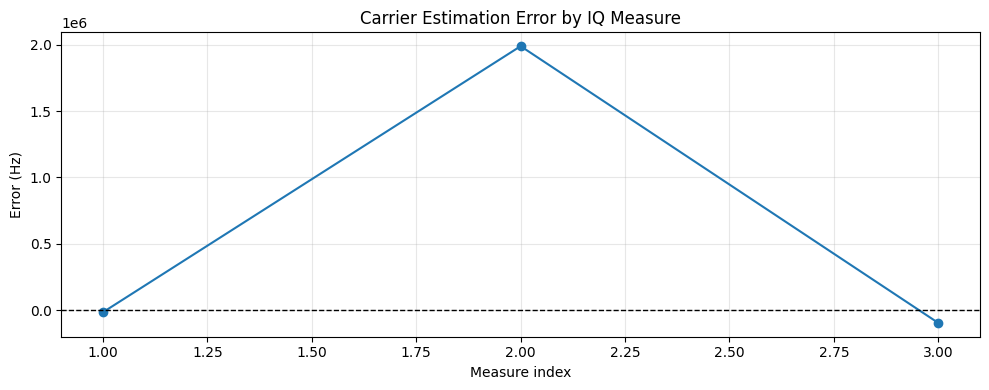

In [4]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from stage1_acquisition import load_iq_records
from stage2_preprocessing import run_stage2
from stage3_spectral_estimation import GainCalibration, run_stage3
from stage4_peak_detection import run_stage4
from stage5_carrier_estimation import FrequencyCalibration, run_stage5
from stage6_confidence_scoring import run_stage6, QualityFlag

FFT_SIZE = 8192
MEASURES = list(range(1, 4))

records = load_iq_records(MEASURES)
results = []
failed = []

for idx, acq_result in enumerate(records, start=1):
    try:
        pre_result = run_stage2(acq_result)
        gain_cal = GainCalibration.from_acquisition_config(acq_result.config)
        spec_result = run_stage3(
            pre_result,
            gain_calibration=gain_cal,
            fft_size=FFT_SIZE,
            n_frames=16,
        )
        peak_result = run_stage4(spec_result)

        if not peak_result.candidates:
            failed.append((idx, "No channel candidates detected"))
            continue

        candidate = peak_result.primary if peak_result.primary is not None else peak_result.candidates[0]

        freq_cal = FrequencyCalibration(residual_hz=0.0)
        carrier_result = run_stage5(
            peak_result=peak_result,
            spec_result=spec_result,
            samples=pre_result.samples,
            freq_cal=freq_cal,
            candidate=candidate,
        )
        final_result = run_stage6(
            est_result=carrier_result,
            pre_result=pre_result,
            acq_result=acq_result,
            spec_fft_size=spec_result.fft_size,
            spec_n_frames=spec_result.averaging_frames,
        )

        flags = QualityFlag.decode(final_result.quality_flags)
        results.append({
            "measure": idx,
            "target_mhz": acq_result.config.target_frequency_hz / 1e6,
            "estimated_mhz": final_result.estimated_frequency_hz / 1e6,
            "error_hz": final_result.deviation_from_target_hz,
            "snr_db": carrier_result.snr_db,
            "confidence": final_result.confidence,
            "flags": ",".join(flags) if flags else "CLEAR",
        })
    except Exception as exc:
        failed.append((idx, str(exc)))

print(f"Processed: {len(results)} / {len(MEASURES)}")
if failed:
    print(f"Failed: {len(failed)}")
    for item in failed[:5]:
        print("  ", item)

if results:
    errors = np.array([r["error_hz"] for r in results], dtype=float)
    confidences = np.array([r["confidence"] for r in results], dtype=float)

    print("\nSummary:")
    print(f"  Mean absolute error (Hz): {np.mean(np.abs(errors)):.2f}")
    print(f"  Median absolute error (Hz): {np.median(np.abs(errors)):.2f}")
    print(f"  Mean confidence: {np.mean(confidences):.2f}")

    for row in results[:10]:
        print(
            f"Measure {row['measure']:02d}: target={row['target_mhz']:.4f} MHz, "
            f"estimated={row['estimated_mhz']:.4f} MHz, error={row['error_hz']:.2f} Hz, "
            f"SNR={row['snr_db']:.2f} dB, conf={row['confidence']:.1f}, flags={row['flags']}"
        )

    plt.figure(figsize=(10, 4))
    plt.plot([r["measure"] for r in results], errors, marker="o")
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.title("Carrier Estimation Error by IQ Measure")
    plt.xlabel("Measure index")
    plt.ylabel("Error (Hz)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()